# Unified Greek-Hedging Comparison Notebook

This notebook refactors the **initial four strategies** so that they are consistent with the newer DGV framework.

## Main design choices
1. **Common starting book** for every strategy: a day-1 **short ATM call** sized to **100,000 underlying shares equivalent**.
2. **Common data source**: the same synthetic market dataset from `fetch_data_hedging.py`.
3. **Persistent option panel**: contracts are tracked by a stable `contract_id = expiry | strike | option_type`.
4. **Common rebalancing engine**: every strategy uses the same daily book update, cashflow logic, and output schema.
5. **Different strategies differ only in the hedge solver**:
   - `delta`
   - `delta_gamma`
   - `delta_vega`
   - `delta_theta`

Later, you can add a **delta-gamma-vega deep-dive solver** in the same notebook and compare it side by side against the first four strategies without changing the rest of the workflow.


## 1. Imports

Make sure `fetch_data_hedging.py` is in the same folder as this notebook.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fetch_data_hedging import (
    build_synthetic_market_dataset,
    black_scholes_price,
    black_scholes_greeks,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 2. User inputs

These settings are shared across **all** strategies so the comparison remains fair.


In [4]:
# ---------------------------------------------------------
# Shared market / sample settings
# ---------------------------------------------------------
TICKER = "AAPL"
MONTHS = 6
END_DATE = None                    # e.g. "2026-03-31"
EXPIRY_DAYS = (7, 14, 21, 30, 45, 60, 90, 120, 150, 180)

# ---------------------------------------------------------
# Shared initial book
# ---------------------------------------------------------
INITIAL_UNDERLYING_SHARES = 100_000
CONTRACT_MULTIPLIER = 100
BASE_OPTION_TYPE = "call"
BASE_POSITION_SIGN = -1            # -1 => short ATM call on day 1
TARGET_ENTRY_DTE = 30

# ---------------------------------------------------------
# Shared hedge search settings
# ---------------------------------------------------------
TARGET_HEDGE_DTE = 30
MAX_SINGLE_CANDIDATES = 20
OPTION_SEARCH_RADIUS = 3           # integer contracts around rounded theoretical hedge
STOCK_ROUND_LOT = 100

# ---------------------------------------------------------
# Shared cash / carrying settings
# ---------------------------------------------------------
USE_DAILY_RISK_FREE_RATE_FOR_CASH = True
MANUAL_CASH_RATE = 0.05            # used only if the flag above is False

# ---------------------------------------------------------
# Strategy list for the initial comparison
# ---------------------------------------------------------
STRATEGIES_TO_RUN = [
    "delta",
    "delta_gamma",
    "delta_vega",
    "delta_theta",
]

EPS = 1e-12


## 3. Load the synthetic market dataset

This notebook uses the same helper file as the newer DGV notebook.


In [5]:
dataset = build_synthetic_market_dataset(
    ticker=TICKER,
    months=MONTHS,
    end_date=END_DATE,
    expiry_days=EXPIRY_DAYS,
)

merged_df = dataset["merged_daily_inputs"].copy()
raw_chain_df = dataset["synthetic_option_chain"].copy()

merged_df["date"] = pd.to_datetime(merged_df["date"])
raw_chain_df["trade_date"] = pd.to_datetime(raw_chain_df["trade_date"])
raw_chain_df["expiry"] = pd.to_datetime(raw_chain_df["expiry"])

print("Merged daily inputs shape:", merged_df.shape)
print("Raw synthetic chain shape:", raw_chain_df.shape)

display(merged_df.head())
display(raw_chain_df.head())


Merged daily inputs shape: (124, 11)
Raw synthetic chain shape: (33860, 19)


,date,open,high,low,close,volume,vix_close,risk_free_rate_pct,risk_free_rate,realized_vol_21d,base_iv
0,2025-10-08,256.519989,258.519989,256.109985,258.059998,36496900,16.299999,3.843,0.03843,NaN,0.1630
1,2025-10-09,257.809998,258.000000,253.139999,254.039993,38322000,16.430000,3.853,0.03853,NaN,0.1643
2,2025-10-10,254.940002,256.380005,244.000000,245.270004,61999100,21.660000,3.853,0.03853,NaN,0.2166
3,2025-10-13,249.380005,249.690002,245.559998,247.660004,38142900,19.030001,3.853,0.03853,NaN,0.1903
4,2025-10-14,246.600006,248.850006,244.699997,247.770004,35478000,20.809999,3.853,0.03853,NaN,0.2081


,trade_date,ticker,spot,expiry,dte,strike,option_type,risk_free_rate,vix_close,base_iv,synthetic_iv,theoretical_price,intrinsic_value,time_value,delta,gamma,vega,theta,rho
0,2025-10-08,AAPL,258.06,2025-10-15,7,200.0,call,0.03843,16.3,0.163,0.178350,58.207346,58.059998,0.147348,1.000000,0.000000,0.000000,-7.680337,3.832791
1,2025-10-08,AAPL,258.06,2025-10-15,7,210.0,call,0.03843,16.3,0.163,0.169643,48.214713,48.059998,0.154716,1.000000,0.000000,0.000000,-8.064354,4.024430
2,2025-10-08,AAPL,258.06,2025-10-15,7,220.0,call,0.03843,16.3,0.163,0.175254,38.222081,38.059998,0.162083,1.000000,0.000000,0.000000,-8.448371,4.216070
3,2025-10-08,AAPL,258.06,2025-10-15,7,230.0,call,0.03843,16.3,0.163,0.181860,28.229451,28.059998,0.169453,0.999998,0.000001,0.000342,-8.833990,4.407699
4,2025-10-08,AAPL,258.06,2025-10-15,7,240.0,call,0.03843,16.3,0.163,0.162232,18.237636,18.059998,0.177639,0.999469,0.000324,0.067182,-9.495257,4.596704


## 4. Rebuild a persistent option panel

The raw synthetic chain is generated independently for each trade date.  
For an iterative backtest, it is cleaner to rebuild a **persistent contract panel** so the same contract can be followed across dates until expiry.


In [6]:
def synthetic_iv_from_inputs(spot, strike, time_to_expiry, base_iv, smile_strength=0.30, term_slope=0.08):
    if time_to_expiry <= 0:
        return np.nan

    log_moneyness = np.log(strike / spot)
    smile_adjustment = 1.0 + smile_strength * abs(log_moneyness)
    term_adjustment = 1.0 + term_slope * (np.sqrt(time_to_expiry) - np.sqrt(30 / 365.0))

    sigma = base_iv * smile_adjustment * term_adjustment
    sigma = float(np.clip(sigma, 0.05, 2.00))
    return sigma


def build_persistent_option_panel(merged_daily_inputs, raw_chain, smile_strength=0.30, term_slope=0.08):
    contract_master = (
        raw_chain[["expiry", "strike", "option_type"]]
        .drop_duplicates()
        .sort_values(["expiry", "option_type", "strike"])
        .reset_index(drop=True)
        .copy()
    )

    contract_master["contract_id"] = (
        contract_master["expiry"].dt.strftime("%Y-%m-%d")
        + "|"
        + contract_master["strike"].round(2).astype(str)
        + "|"
        + contract_master["option_type"]
    )

    rows = []

    daily_inputs = merged_daily_inputs.copy().sort_values("date")

    for _, day_row in daily_inputs.iterrows():
        trade_date = pd.Timestamp(day_row["date"])
        spot = float(day_row["close"])
        r = float(day_row["risk_free_rate"])
        base_iv = float(day_row["base_iv"])

        live_contracts = contract_master.loc[contract_master["expiry"] >= trade_date].copy()

        for _, c in live_contracts.iterrows():
            expiry = pd.Timestamp(c["expiry"])
            strike = float(c["strike"])
            option_type = c["option_type"]
            contract_id = c["contract_id"]

            dte_days = (expiry - trade_date).days
            T = dte_days / 365.0

            sigma = synthetic_iv_from_inputs(
                spot=spot,
                strike=strike,
                time_to_expiry=T,
                base_iv=base_iv,
                smile_strength=smile_strength,
                term_slope=term_slope,
            )

            price = black_scholes_price(spot, strike, T, r, sigma, option_type=option_type)
            delta, gamma, vega, theta, rho = black_scholes_greeks(
                spot, strike, T, r, sigma, option_type=option_type
            )

            rows.append(
                {
                    "trade_date": trade_date,
                    "contract_id": contract_id,
                    "expiry": expiry,
                    "dte": dte_days,
                    "strike": strike,
                    "option_type": option_type,
                    "spot": spot,
                    "risk_free_rate": r,
                    "base_iv": base_iv,
                    "synthetic_iv": sigma,
                    "theoretical_price": price,
                    "delta": delta,
                    "gamma": gamma,
                    "vega": vega,
                    "theta": theta,
                    "rho": rho,
                }
            )

    panel = (
        pd.DataFrame(rows)
        .sort_values(["trade_date", "expiry", "option_type", "strike"])
        .reset_index(drop=True)
    )
    return panel


def classify_vix(vix_value):
    if pd.isna(vix_value):
        return "medium"
    if vix_value < 15:
        return "low"
    elif vix_value <= 25:
        return "medium"
    return "high"


In [7]:
panel_df = build_persistent_option_panel(merged_df, raw_chain_df)

regime_df = merged_df[["date", "vix_close"]].copy()
regime_df = regime_df.rename(columns={"date": "trade_date"})
regime_df["trade_date"] = pd.to_datetime(regime_df["trade_date"])
regime_df["regime"] = regime_df["vix_close"].apply(classify_vix)

print("Persistent option panel shape:", panel_df.shape)
display(panel_df.head())
display(regime_df.head())


Persistent option panel shape: (1161222, 16)


,trade_date,contract_id,expiry,dte,strike,option_type,spot,risk_free_rate,base_iv,synthetic_iv,theoretical_price,delta,gamma,vega,theta,rho
0,2025-10-08,2025-10-15|200.0|call,2025-10-15,7,200.0,call,258.059998,0.03843,0.163,0.173383,58.207346,1.000000,1.393238e-26,3.085164e-24,-7.680337,3.832791
1,2025-10-08,2025-10-15|210.0|call,2025-10-15,7,210.0,call,258.059998,0.03843,0.163,0.171025,48.214713,1.000000,1.626832e-18,3.553449e-16,-8.064354,4.024430
2,2025-10-08,2025-10-15|220.0|call,2025-10-15,7,220.0,call,258.059998,0.03843,0.163,0.168778,38.222081,1.000000,3.729482e-12,8.039143e-10,-8.448371,4.216070
3,2025-10-08,2025-10-15|230.0|call,2025-10-15,7,230.0,call,258.059998,0.03843,0.163,0.166630,28.229449,1.000000,2.126799e-07,4.526111e-05,-8.832582,4.407708
4,2025-10-08,2025-10-15|240.0|call,2025-10-15,7,240.0,call,258.059998,0.03843,0.163,0.164573,18.237806,0.999375,3.714789e-04,7.807999e-02,-9.545182,4.596236


,trade_date,vix_close,regime
0,2025-10-08,16.299999,medium
1,2025-10-09,16.430000,medium
2,2025-10-10,21.660000,medium
3,2025-10-13,19.030001,medium
4,2025-10-14,20.809999,medium


## 5. Common helper functions

These are shared by all strategies:
- choose the day-1 ATM base contract
- value a portfolio snapshot
- build a common daily candidate set
- compute trades and common daily tables


In [12]:
def choose_initial_atm_contract(day_panel, target_dte=30, option_type="call"):
    df = day_panel.loc[day_panel["option_type"] == option_type].copy()
    df["atm_distance"] = (df["strike"] - df["spot"]).abs()
    df["dte_distance"] = (df["dte"] - target_dte).abs()

    chosen = (
        df.sort_values(["atm_distance", "dte_distance", "expiry", "strike"])
        .iloc[0]
    )
    return chosen


def clean_position_book(position_book, day_panel):
    live_ids = set(day_panel["contract_id"].unique())
    cleaned = {
        cid: qty
        for cid, qty in position_book.items()
        if (cid in live_ids) and (abs(qty) > EPS)
    }
    return cleaned


def round_to_lot(x, lot_size=100):
    if not np.isfinite(x):
        return 0.0
    return float(np.round(x / lot_size) * lot_size)


def position_differences(current_book, target_book):
    all_ids = set(current_book) | set(target_book)
    diffs = {}

    for cid in all_ids:
        current_qty = float(current_book.get(cid, 0.0))
        target_qty = float(target_book.get(cid, 0.0))
        trade_qty = target_qty - current_qty

        if abs(trade_qty) > EPS:
            diffs[cid] = float(trade_qty)

    return diffs


def portfolio_snapshot(day_panel, option_positions, stock_position=0.0, contract_multiplier=100):
    df = day_panel.set_index("contract_id")

    rows = []
    total_delta = float(stock_position)
    total_gamma = 0.0
    total_vega = 0.0
    total_theta = 0.0
    total_option_value = 0.0

    for cid, qty_contracts in option_positions.items():
        if cid not in df.index:
            continue

        row = df.loc[cid]
        qty_shares_equiv = qty_contracts * contract_multiplier

        pos_delta = qty_shares_equiv * float(row["delta"])
        pos_gamma = qty_shares_equiv * float(row["gamma"])
        pos_vega = qty_shares_equiv * float(row["vega"])
        pos_theta = qty_shares_equiv * float(row["theta"])
        pos_value = qty_shares_equiv * float(row["theoretical_price"])

        rows.append(
            {
                "contract_id": cid,
                "quantity_contracts": qty_contracts,
                "quantity_shares_equiv": qty_shares_equiv,
                "price_per_share": float(row["theoretical_price"]),
                "delta_per_share": float(row["delta"]),
                "gamma_per_share": float(row["gamma"]),
                "vega_per_share": float(row["vega"]),
                "theta_per_share": float(row["theta"]),
                "position_delta": pos_delta,
                "position_gamma": pos_gamma,
                "position_vega": pos_vega,
                "position_theta": pos_theta,
                "position_value": pos_value,
            }
        )

        total_delta += pos_delta
        total_gamma += pos_gamma
        total_vega += pos_vega
        total_theta += pos_theta
        total_option_value += pos_value

    details = pd.DataFrame(rows)

    summary = {
        "stock_position_shares": float(stock_position),
        "option_value": float(total_option_value),
        "total_delta": float(total_delta),
        "total_gamma": float(total_gamma),
        "total_vega": float(total_vega),
        "total_theta": float(total_theta),
    }
    return summary, details


def select_daily_candidates(day_panel, target_dte=30, option_type="call", max_candidates=20, exclude_contract_ids=None):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    df = day_panel.copy()
    df = df.loc[(df["option_type"] == option_type) & (~df["contract_id"].isin(exclude_contract_ids))].copy()
    numeric_cols = [
        "strike", "spot", "dte", "theoretical_price",
        "delta", "gamma", "vega", "theta",
    ]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[col for col in numeric_cols if col in df.columns])

    if len(df) == 0:
        return df.reset_index(drop=True)

    df["atm_score"] = np.abs(np.log(df["strike"] / df["spot"]))
    df["dte_score"] = np.abs(df["dte"] - target_dte) / 365.0
    df["candidate_score"] = df["atm_score"] + 0.50 * df["dte_score"]

    return (
        df.sort_values(["candidate_score", "expiry", "strike"])
        .head(max_candidates)
        .reset_index(drop=True)
    )


def build_base_only_book(base_contract_id, base_contracts):
    return {base_contract_id: float(base_contracts)}


def build_live_base_book(day_panel, base_contract_id, base_contracts):
    return clean_position_book(
        {base_contract_id: float(base_contracts)},
        day_panel,
    )


## 6. Strategy solvers for the initial four strategies

Important change relative to the original notebook:

- every strategy now uses the **same base book**
- every strategy uses the **same persistent panel**
- every strategy returns the **same type of target book**
- later, the DGV solver can be added using the same interface


In [13]:
def solve_delta(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    target_option_book = build_live_base_book(day_panel, base_contract_id, base_contracts)

    summary_no_stock, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=target_option_book,
        stock_position=0.0,
        contract_multiplier=contract_multiplier,
    )

    stock_position_theory = -summary_no_stock["total_delta"]
    if not np.isfinite(stock_position_theory):
        stock_position_theory = 0.0
    stock_position_actual = round_to_lot(stock_position_theory, stock_round_lot)

    return {
        "selected_hedge_id": None,
        "target_option_book": target_option_book,
        "target_stock_position": float(stock_position_actual),
        "hedge_contracts_theory": np.nan,
        "hedge_contracts_actual": 0.0,
        "stock_position_theory": float(stock_position_theory),
        "stock_position_actual": float(stock_position_actual),
        "targeted_greek": "delta",
        "residual_objective": float(abs(summary_no_stock["total_delta"] + stock_position_actual)),
    }


def solve_single_greek_strategy(
    day_panel,
    base_contract_id,
    base_contracts,
    greek_name,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    base_book = build_live_base_book(day_panel, base_contract_id, base_contracts)
    base_summary, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=base_book,
        stock_position=0.0,
        contract_multiplier=contract_multiplier,
    )
    base_total_greek = float(base_summary[f"total_{greek_name}"])

    if not np.isfinite(base_total_greek):
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    candidates = select_daily_candidates(
        day_panel=day_panel,
        target_dte=target_hedge_dte,
        option_type="call",
        max_candidates=max_candidates,
        exclude_contract_ids={base_contract_id},
    )

    if len(candidates) == 0:
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    best = None

    for _, row in candidates.iterrows():
        greek_per_share = float(row[greek_name])

        if (not np.isfinite(greek_per_share)) or (abs(greek_per_share) < EPS):
            continue

        hedge_contracts_theory = -base_total_greek / (contract_multiplier * greek_per_share)
        if not np.isfinite(hedge_contracts_theory):
            continue
        hedge_contracts_center = int(np.round(hedge_contracts_theory))

        for hedge_contracts_actual in range(
            hedge_contracts_center - option_search_radius,
            hedge_contracts_center + option_search_radius + 1,
        ):
            target_option_book = dict(base_book)

            if abs(hedge_contracts_actual) > EPS:
                target_option_book[row["contract_id"]] = float(hedge_contracts_actual)

            summary_no_stock, _ = portfolio_snapshot(
                day_panel=day_panel,
                option_positions=target_option_book,
                stock_position=0.0,
                contract_multiplier=contract_multiplier,
            )

            stock_position_theory = -summary_no_stock["total_delta"]
            if not np.isfinite(stock_position_theory):
                continue
            stock_position_actual = round_to_lot(stock_position_theory, stock_round_lot)

            final_summary, _ = portfolio_snapshot(
                day_panel=day_panel,
                option_positions=target_option_book,
                stock_position=stock_position_actual,
                contract_multiplier=contract_multiplier,
            )
            if not all(np.isfinite(final_summary[key]) for key in ["total_delta", f"total_{greek_name}"]):
                continue

            if greek_name == "gamma":
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary["total_gamma"]) / 0.1) ** 2
                )
            elif greek_name == "vega":
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary["total_vega"]) / 1000.0) ** 2
                )
            else:
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary["total_theta"]) / 1000.0) ** 2
                )

            candidate_solution = {
                "selected_hedge_id": row["contract_id"],
                "target_option_book": target_option_book,
                "target_stock_position": float(stock_position_actual),
                "hedge_contracts_theory": float(hedge_contracts_theory),
                "hedge_contracts_actual": float(hedge_contracts_actual),
                "stock_position_theory": float(stock_position_theory),
                "stock_position_actual": float(stock_position_actual),
                "targeted_greek": greek_name,
                "residual_objective": float(residual_objective),
            }

            if (best is None) or (candidate_solution["residual_objective"] < best["residual_objective"]):
                best = candidate_solution

    if best is None:
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    return best


def solve_delta_gamma(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="gamma",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


def solve_delta_vega(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="vega",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


def solve_delta_theta(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="theta",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


STRATEGY_SOLVERS = {
    "delta": solve_delta,
    "delta_gamma": solve_delta_gamma,
    "delta_vega": solve_delta_vega,
    "delta_theta": solve_delta_theta,
}


## 7. Common backtest engine

This is the key refactor.  
The daily loop is shared across all strategies.  
Only the solver changes.


In [14]:
def run_strategy_backtest(
    panel_df,
    regime_df,
    strategy_name,
    initial_underlying_shares=100_000,
    base_option_type="call",
    base_position_sign=-1,
    target_entry_dte=30,
    target_hedge_dte=30,
    contract_multiplier=100,
    max_single_candidates=20,
    option_search_radius=3,
    stock_round_lot=100,
    use_daily_risk_free_rate_for_cash=True,
    manual_cash_rate=0.05,
):
    if strategy_name not in STRATEGY_SOLVERS:
        raise ValueError(f"Unknown strategy: {strategy_name}")

    dates = sorted(pd.to_datetime(panel_df["trade_date"]).unique())
    first_date = dates[0]

    day1_panel = panel_df.loc[panel_df["trade_date"] == first_date].copy()

    entry_contract = choose_initial_atm_contract(
        day_panel=day1_panel,
        target_dte=target_entry_dte,
        option_type=base_option_type,
    )

    base_contract_id = entry_contract["contract_id"]
    base_contracts = base_position_sign * (initial_underlying_shares / contract_multiplier)

    position_book = {base_contract_id: float(base_contracts)}
    stock_position = 0.0
    cumulative_cash_outflow_after_interest = 0.0

    history_rows = []
    trade_log_rows = []

    strategy_fn = STRATEGY_SOLVERS[strategy_name]

    for trade_date in dates:
        day_panel = panel_df.loc[panel_df["trade_date"] == trade_date].copy()
        option_row_map = day_panel.set_index("contract_id")

        position_book = clean_position_book(position_book, day_panel)

        spot_t = float(day_panel["spot"].iloc[0])
        r_cash_t = (
            float(day_panel["risk_free_rate"].iloc[0])
            if use_daily_risk_free_rate_for_cash
            else manual_cash_rate
        )

        pre_summary, _ = portfolio_snapshot(
            day_panel=day_panel,
            option_positions=position_book,
            stock_position=stock_position,
            contract_multiplier=contract_multiplier,
        )

        base_row = None
        if base_contract_id in set(day_panel["contract_id"]):
            base_row = day_panel.loc[day_panel["contract_id"] == base_contract_id].iloc[0]

        proposal = strategy_fn(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_single_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

        target_option_book = clean_position_book(proposal["target_option_book"], day_panel)
        target_stock_position = float(proposal["target_stock_position"])

        option_trades = position_differences(position_book, target_option_book)
        stock_trade_shares = float(target_stock_position - stock_position)

        option_trade_cashflow = 0.0
        hedge_trade_count = 0

        for cid, trade_qty_contracts in option_trades.items():
            px = float(option_row_map.loc[cid, "theoretical_price"])
            cashflow = trade_qty_contracts * contract_multiplier * px
            option_trade_cashflow += cashflow

            if cid != base_contract_id:
                hedge_trade_count += 1

            trade_log_rows.append(
                {
                    "trade_date": trade_date,
                    "strategy": strategy_name,
                    "instrument_type": "option",
                    "contract_id": cid,
                    "trade_quantity_contracts": float(trade_qty_contracts),
                    "trade_quantity_shares_equiv": float(trade_qty_contracts * contract_multiplier),
                    "price_per_share": px,
                    "trade_cashflow": float(cashflow),
                }
            )

        stock_trade_cashflow = stock_trade_shares * spot_t

        if abs(stock_trade_shares) > EPS:
            trade_log_rows.append(
                {
                    "trade_date": trade_date,
                    "strategy": strategy_name,
                    "instrument_type": "stock",
                    "contract_id": "STOCK",
                    "trade_quantity_contracts": np.nan,
                    "trade_quantity_shares_equiv": float(stock_trade_shares),
                    "price_per_share": float(spot_t),
                    "trade_cashflow": float(stock_trade_cashflow),
                }
            )

        total_trade_cashflow = option_trade_cashflow + stock_trade_cashflow

        cumulative_cash_outflow_before_interest = (
            cumulative_cash_outflow_after_interest + total_trade_cashflow
        )
        interest_cost = cumulative_cash_outflow_before_interest * (r_cash_t / 252.0)
        cumulative_cash_outflow_after_interest = (
            cumulative_cash_outflow_before_interest + interest_cost
        )

        position_book = clean_position_book(target_option_book, day_panel)
        stock_position = float(target_stock_position)

        post_summary, _ = portfolio_snapshot(
            day_panel=day_panel,
            option_positions=position_book,
            stock_position=stock_position,
            contract_multiplier=contract_multiplier,
        )

        regime_value = "medium"
        regime_match = regime_df.loc[regime_df["trade_date"] == trade_date]
        if len(regime_match) > 0:
            regime_value = regime_match["regime"].iloc[0]

        history_rows.append(
            {
                "trade_date": trade_date,
                "strategy": strategy_name,
                "regime": regime_value,
                "spot": float(spot_t),
                "base_contract_id": base_contract_id,
                "base_strike": float(base_row["strike"]) if base_row is not None else np.nan,
                "base_dte": int(base_row["dte"]) if base_row is not None else np.nan,
                "base_option_price_per_share": float(base_row["theoretical_price"]) if base_row is not None else np.nan,
                "base_delta_per_share": float(base_row["delta"]) if base_row is not None else np.nan,
                "base_gamma_per_share": float(base_row["gamma"]) if base_row is not None else np.nan,
                "base_vega_per_share": float(base_row["vega"]) if base_row is not None else np.nan,
                "base_theta_per_share": float(base_row["theta"]) if base_row is not None else np.nan,
                "base_contracts_held": float(base_contracts),
                "selected_hedge_id": proposal["selected_hedge_id"],
                "targeted_greek": proposal["targeted_greek"],
                "pre_delta": float(pre_summary["total_delta"]),
                "pre_gamma": float(pre_summary["total_gamma"]),
                "pre_vega": float(pre_summary["total_vega"]),
                "pre_theta": float(pre_summary["total_theta"]),
                "hedge_contracts_theory": proposal["hedge_contracts_theory"],
                "hedge_contracts_actual": proposal["hedge_contracts_actual"],
                "stock_position_theory": proposal["stock_position_theory"],
                "stock_position_actual": proposal["stock_position_actual"],
                "stock_trade_shares": float(stock_trade_shares),
                "stock_position_after_trade": float(stock_position),
                "post_delta": float(post_summary["total_delta"]),
                "post_gamma": float(post_summary["total_gamma"]),
                "post_vega": float(post_summary["total_vega"]),
                "post_theta": float(post_summary["total_theta"]),
                "option_trade_cashflow": float(option_trade_cashflow),
                "stock_trade_cashflow": float(stock_trade_cashflow),
                "total_trade_cashflow": float(total_trade_cashflow),
                "cumulative_cash_outflow_before_interest": float(cumulative_cash_outflow_before_interest),
                "interest_cost": float(interest_cost),
                "cumulative_cash_outflow_after_interest": float(cumulative_cash_outflow_after_interest),
                "gross_option_turnover_contracts": float(sum(abs(v) for v in option_trades.values())),
                "gross_stock_turnover_shares": float(abs(stock_trade_shares)),
                "hedge_trade_count": int(hedge_trade_count),
                "residual_objective": float(proposal["residual_objective"]),
            }
        )

    history_df = pd.DataFrame(history_rows)
    trade_log_df = pd.DataFrame(trade_log_rows)
    return history_df, trade_log_df


def run_multiple_strategies(
    panel_df,
    regime_df,
    strategies_to_run,
    initial_underlying_shares=100_000,
    base_option_type="call",
    base_position_sign=-1,
    target_entry_dte=30,
    target_hedge_dte=30,
    contract_multiplier=100,
    max_single_candidates=20,
    option_search_radius=3,
    stock_round_lot=100,
    use_daily_risk_free_rate_for_cash=True,
    manual_cash_rate=0.05,
):
    history_frames = []
    trade_log_frames = []

    for strategy_name in strategies_to_run:
        hist_df, log_df = run_strategy_backtest(
            panel_df=panel_df,
            regime_df=regime_df,
            strategy_name=strategy_name,
            initial_underlying_shares=initial_underlying_shares,
            base_option_type=base_option_type,
            base_position_sign=base_position_sign,
            target_entry_dte=target_entry_dte,
            target_hedge_dte=target_hedge_dte,
            contract_multiplier=contract_multiplier,
            max_single_candidates=max_single_candidates,
            option_search_radius=option_search_radius,
            stock_round_lot=stock_round_lot,
            use_daily_risk_free_rate_for_cash=use_daily_risk_free_rate_for_cash,
            manual_cash_rate=manual_cash_rate,
        )

        history_frames.append(hist_df)
        trade_log_frames.append(log_df)

    combined_history_df = pd.concat(history_frames, ignore_index=True)
    combined_trade_log_df = pd.concat(trade_log_frames, ignore_index=True)

    return combined_history_df, combined_trade_log_df


def build_strategy_daily_table(history_df, strategy_name):
    cols = [
        "trade_date",
        "strategy",
        "regime",
        "spot",
        "base_dte",
        "base_option_price_per_share",
        "base_delta_per_share",
        "base_gamma_per_share",
        "base_vega_per_share",
        "base_theta_per_share",
        "base_contracts_held",
        "selected_hedge_id",
        "targeted_greek",
        "pre_delta",
        "pre_gamma",
        "pre_vega",
        "pre_theta",
        "hedge_contracts_theory",
        "hedge_contracts_actual",
        "stock_position_theory",
        "stock_position_actual",
        "stock_trade_shares",
        "post_delta",
        "post_gamma",
        "post_vega",
        "post_theta",
        "total_trade_cashflow",
        "cumulative_cash_outflow_before_interest",
        "interest_cost",
        "cumulative_cash_outflow_after_interest",
    ]
    return history_df.loc[history_df["strategy"] == strategy_name, cols].copy()


def summarise_results(combined_history_df):
    summary_df = (
        combined_history_df
        .groupby(["strategy", "regime"], as_index=False)
        .agg(
            n_days=("trade_date", "count"),
            mean_abs_post_delta=("post_delta", lambda s: float(np.mean(np.abs(s)))),
            mean_abs_post_gamma=("post_gamma", lambda s: float(np.mean(np.abs(s)))),
            mean_abs_post_vega=("post_vega", lambda s: float(np.mean(np.abs(s)))),
            mean_abs_post_theta=("post_theta", lambda s: float(np.mean(np.abs(s)))),
            total_option_turnover=("gross_option_turnover_contracts", "sum"),
            total_stock_turnover=("gross_stock_turnover_shares", "sum"),
            final_cash_outflow=("cumulative_cash_outflow_after_interest", "last"),
            avg_daily_cashflow=("total_trade_cashflow", "mean"),
        )
        .sort_values(["strategy", "regime"])
        .reset_index(drop=True)
    )
    return summary_df


## 8. Run the initial four strategies under the same assumptions


In [15]:
combined_history_df, combined_trade_log_df = run_multiple_strategies(
    panel_df=panel_df,
    regime_df=regime_df,
    strategies_to_run=STRATEGIES_TO_RUN,
    initial_underlying_shares=INITIAL_UNDERLYING_SHARES,
    base_option_type=BASE_OPTION_TYPE,
    base_position_sign=BASE_POSITION_SIGN,
    target_entry_dte=TARGET_ENTRY_DTE,
    target_hedge_dte=TARGET_HEDGE_DTE,
    contract_multiplier=CONTRACT_MULTIPLIER,
    max_single_candidates=MAX_SINGLE_CANDIDATES,
    option_search_radius=OPTION_SEARCH_RADIUS,
    stock_round_lot=STOCK_ROUND_LOT,
    use_daily_risk_free_rate_for_cash=USE_DAILY_RISK_FREE_RATE_FOR_CASH,
    manual_cash_rate=MANUAL_CASH_RATE,
)

print("Combined history shape:", combined_history_df.shape)
print("Combined trade log shape:", combined_trade_log_df.shape)

display(combined_history_df.head())
display(combined_trade_log_df.head())


Combined history shape: (496, 39)
Combined trade log shape: (222, 8)


,trade_date,strategy,regime,spot,base_contract_id,base_strike,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_theta_per_share,base_contracts_held,selected_hedge_id,targeted_greek,pre_delta,pre_gamma,pre_vega,pre_theta,hedge_contracts_theory,hedge_contracts_actual,stock_position_theory,stock_position_actual,stock_trade_shares,stock_position_after_trade,post_delta,post_gamma,post_vega,post_theta,option_trade_cashflow,stock_trade_cashflow,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest,gross_option_turnover_contracts,gross_stock_turnover_shares,hedge_trade_count,residual_objective
0,2025-10-08,delta,medium,258.059998,2025-11-07|260.0|call,260.0,30.0,4.292413,0.472474,0.032929,29.444864,-33.783320,-1000.0,None,delta,-47247.402167,-3292.892029,-2.944486e+06,3.378332e+06,NaN,0.0,47247.402167,47200.0,47200.0,47200.0,-47.402167,-3292.892029,-2.944486e+06,3.378332e+06,0.0,1.218043e+07,1.218043e+07,1.218043e+07,1857.515831,1.218229e+07,0.0,47200.0,0,47.402167
1,2025-10-09,delta,medium,254.039993,2025-11-07|260.0|call,260.0,29.0,2.627328,0.341457,0.030991,26.280318,-30.592213,-1000.0,None,delta,13054.307618,-3099.133366,-2.628032e+06,3.059221e+06,NaN,0.0,34145.692382,34100.0,-13100.0,34100.0,-45.692382,-3099.133366,-2.628032e+06,3.059221e+06,0.0,-3.327924e+06,-3.327924e+06,8.854365e+06,1353.804348,8.855719e+06,0.0,13100.0,0,45.692382
2,2025-10-10,delta,medium,245.270004,2025-11-07|260.0|call,260.0,28.0,1.522411,0.190179,0.018150,18.445153,-28.213864,-1000.0,None,delta,15082.124870,-1814.991922,-1.844515e+06,2.821386e+06,NaN,0.0,19017.875130,19000.0,-15100.0,19000.0,-17.875130,-1814.991922,-1.844515e+06,2.821386e+06,0.0,-3.703577e+06,-3.703577e+06,5.152142e+06,787.746176,5.152930e+06,0.0,15100.0,0,17.875130
3,2025-10-13,delta,medium,247.660004,2025-11-07|260.0|call,260.0,25.0,1.255529,0.187628,0.021560,17.453069,-26.292190,-1000.0,None,delta,237.177161,-2156.022806,-1.745307e+06,2.629219e+06,NaN,0.0,18762.822839,18800.0,-200.0,18800.0,37.177161,-2156.022806,-1.745307e+06,2.629219e+06,0.0,-4.953200e+04,-4.953200e+04,5.103398e+06,780.293334,5.104178e+06,0.0,200.0,0,37.177161
4,2025-10-14,delta,medium,247.770004,2025-11-07|260.0|call,260.0,24.0,1.517868,0.206597,0.021333,18.135032,-30.955486,-1000.0,None,delta,-1859.726946,-2133.294570,-1.813503e+06,3.095549e+06,NaN,0.0,20659.726946,20700.0,1900.0,20700.0,40.273054,-2133.294570,-1.813503e+06,3.095549e+06,0.0,4.707630e+05,4.707630e+05,5.574941e+06,852.390806,5.575794e+06,0.0,1900.0,0,40.273054


,trade_date,strategy,instrument_type,contract_id,trade_quantity_contracts,trade_quantity_shares_equiv,price_per_share,trade_cashflow
0,2025-10-08,delta,stock,STOCK,NaN,47200.0,258.059998,1.218043e+07
1,2025-10-09,delta,stock,STOCK,NaN,-13100.0,254.039993,-3.327924e+06
2,2025-10-10,delta,stock,STOCK,NaN,-15100.0,245.270004,-3.703577e+06
3,2025-10-13,delta,stock,STOCK,NaN,-200.0,247.660004,-4.953200e+04
4,2025-10-14,delta,stock,STOCK,NaN,1900.0,247.770004,4.707630e+05


## 9. Daily tables in a common schema

These are the tables you can compare later with the DGV strategy.


In [16]:
delta_daily_table = build_strategy_daily_table(combined_history_df, "delta")
delta_gamma_daily_table = build_strategy_daily_table(combined_history_df, "delta_gamma")
delta_vega_daily_table = build_strategy_daily_table(combined_history_df, "delta_vega")
delta_theta_daily_table = build_strategy_daily_table(combined_history_df, "delta_theta")

display(delta_gamma_daily_table.head(15))


,trade_date,strategy,regime,spot,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_theta_per_share,base_contracts_held,selected_hedge_id,targeted_greek,pre_delta,pre_gamma,pre_vega,pre_theta,hedge_contracts_theory,hedge_contracts_actual,stock_position_theory,stock_position_actual,stock_trade_shares,post_delta,post_gamma,post_vega,post_theta,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest
124,2025-10-08,delta_gamma,medium,258.059998,30.0,4.292413,0.472474,0.032929,29.444864,-33.783320,-1000.0,2025-11-04|255.0|call,gamma,-47247.402167,-3292.892029,-2.944486e+06,3.378332e+06,1007.993877,1008.0,-17119.584350,-17100.0,-17100.0,19.584350,0.020004,-2.940345e+05,-161288.996027,-3.739322e+06,-3.739322e+06,-570.246601,-3.739892e+06
125,2025-10-09,delta_gamma,medium,254.039993,29.0,2.627328,0.341457,0.030991,26.280318,-30.592213,-1000.0,2025-11-04|255.0|call,gamma,-906.849739,512.364622,9.851167e+04,-5.597308e+05,864.994648,865.0,-9051.826354,-9100.0,8000.0,-48.173646,0.019174,-2.882896e+05,-46327.892582,1.970619e+06,-1.769273e+06,-270.516252,-1.769544e+06
126,2025-10-10,delta_gamma,medium,245.270004,28.0,1.522411,0.190179,0.018150,18.445153,-28.213864,-1000.0,2025-11-07|250.0|call,gamma,-4539.150777,232.137552,1.195564e+02,-3.386794e+05,692.004257,692.0,-9082.333795,-9100.0,0.0,-17.666205,-0.011164,-2.134098e+04,-19705.661117,9.067039e+04,-1.678873e+06,-256.694398,-1.679130e+06
127,2025-10-13,delta_gamma,medium,247.660004,25.0,1.255529,0.187628,0.021560,17.453069,-26.292190,-1000.0,2025-11-15|250.0|call,gamma,3684.580296,66.658875,3.309438e+04,-1.333195e+05,771.006357,771.0,-17502.702559,-17500.0,-8400.0,2.702559,-0.017778,5.388757e+05,-115417.591760,-1.982759e+06,-3.661889e+06,-559.891128,-3.662448e+06
128,2025-10-14,delta_gamma,medium,247.770004,24.0,1.517868,0.206597,0.021333,18.135032,-30.955486,-1000.0,2025-11-12|245.0|call,gamma,-1434.693534,-129.019131,4.390570e+05,7.858113e+04,808.982226,809.0,-28478.840766,-28500.0,-11000.0,-21.159234,0.046870,3.583472e+05,-202284.393668,-2.523245e+06,-6.185693e+06,-945.772847,-6.186639e+06
129,2025-10-15,delta_gamma,medium,249.339996,23.0,1.733197,0.233417,0.023471,19.162330,-33.864867,-1000.0,2025-11-22|250.0|call,gamma,764.835629,-254.865357,1.525870e+05,1.114589e+05,981.977794,982.0,-27871.359699,-27900.0,600.0,-28.640301,0.053077,1.230983e+06,-211515.178754,1.278251e+05,-6.058814e+06,-927.575575,-6.059742e+06
130,2025-10-16,delta_gamma,high,247.449997,22.0,2.087433,0.236146,0.019812,18.718980,-41.924939,-1000.0,2025-11-14|245.0|call,gamma,-3895.083829,-28.875349,1.212378e+06,-1.060947e+05,900.032506,900.0,-29139.698820,-29100.0,-1200.0,39.698820,-0.071553,5.738047e+05,-185808.303354,-2.242489e+05,-6.283990e+06,-960.802165,-6.284951e+06
131,2025-10-17,delta_gamma,medium,252.289993,21.0,2.317723,0.297457,0.027399,20.959349,-40.835749,-1000.0,2025-11-23|250.0|call,gamma,6022.023659,-672.709494,1.829626e+04,6.065836e+05,1182.961803,1183.0,-40107.045892,-40100.0,-11000.0,7.045892,0.088468,1.597123e+06,-358850.428134,-2.736214e+06,-9.021165e+06,-1371.789854,-9.022537e+06
132,2025-10-20,delta_gamma,medium,262.239990,18.0,5.705235,0.609889,0.036238,22.345607,-47.051779,-1000.0,2025-11-21|260.0|call,gamma,-3431.670163,-1570.148416,2.016845e+05,1.376218e+06,1330.004948,1330.0,-18482.612423,-18500.0,21600.0,-17.387577,-0.013482,1.761624e+06,-217953.566190,4.916416e+06,-4.106120e+06,-618.851011,-4.106739e+06
133,2025-10-21,delta_gamma,medium,262.769989,17.0,5.826746,0.633275,0.037243,21.349210,-46.931416,-1000.0,2025-11-12|265.0|call,gamma,-132.534951,-20.271662,1.760536e+06,-1.946746e+05,1082.997578,1083.0,14298.712213,14300.0,32800.0,1.287787,0.008328,6.327469e+05,121622.919461,8.046520e+06,3.939781e+06,591.748828,3.940372e+06


## 10. Strategy comparison by market regime


In [17]:
summary_df = summarise_results(combined_history_df)
display(summary_df)


,strategy,regime,n_days,mean_abs_post_delta,mean_abs_post_gamma,mean_abs_post_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,delta,high,15,0.972421,132.077513,124793.199877,279499.594333,0.0,300.0,-318617.681900,4948.999939
1,delta,low,13,0.000000,0.000000,0.000000,0.000000,0.0,0.0,-316130.941781,0.000000
2,delta,medium,96,6.154950,514.486318,298821.744640,695651.719787,0.0,292300.0,-318754.694494,-4700.736277
3,delta_gamma,high,15,2.646588,0.004770,38253.646207,12387.220224,1882.0,1200.0,-570866.128520,-14949.924548
4,delta_gamma,low,13,0.000000,0.000000,0.000000,0.000000,0.0,0.0,-566410.645399,0.000000
5,delta_gamma,medium,96,4.212043,0.012247,213371.211617,91770.451434,31350.0,387200.0,-571111.613483,-3798.832738
6,delta_theta,high,15,0.591904,3.106387,39993.305029,27.498758,1575.0,6000.0,-556478.187331,-84016.664549
7,delta_theta,low,13,0.000000,0.000000,0.000000,0.000000,0.0,0.0,-552134.998890,0.000000
8,delta_theta,medium,96,5.541435,68.533007,256392.935727,19.036968,35407.0,337400.0,-556717.485163,7280.551545
9,delta_vega,high,15,0.875783,53.084760,1.655955,105571.637728,1419.0,12900.0,-578942.786089,215602.708627


## 11. Side-by-side plots for the initial four strategies

These are deliberately kept generic so that later you can append the DGV strategy and rerun the same plotting cells.


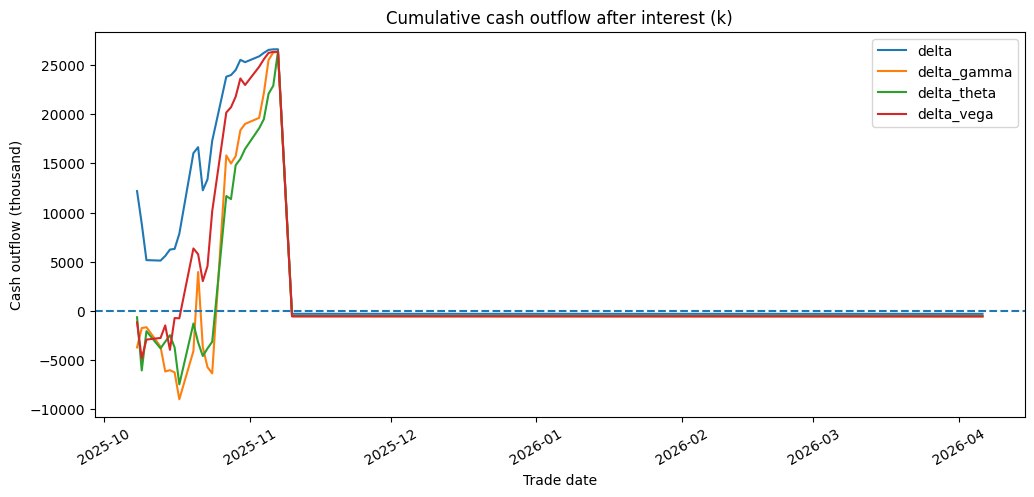

In [18]:
plt.figure(figsize=(12, 5))

for strategy_name, sub in combined_history_df.groupby("strategy"):
    sub = sub.sort_values("trade_date")
    plt.plot(
        sub["trade_date"],
        sub["cumulative_cash_outflow_after_interest"] / 1000.0,
        label=strategy_name,
    )

plt.axhline(0.0, linestyle="--")
plt.title("Cumulative cash outflow after interest (k)")
plt.xlabel("Trade date")
plt.ylabel("Cash outflow (thousand)")
plt.legend()
plt.xticks(rotation=30)
plt.show()


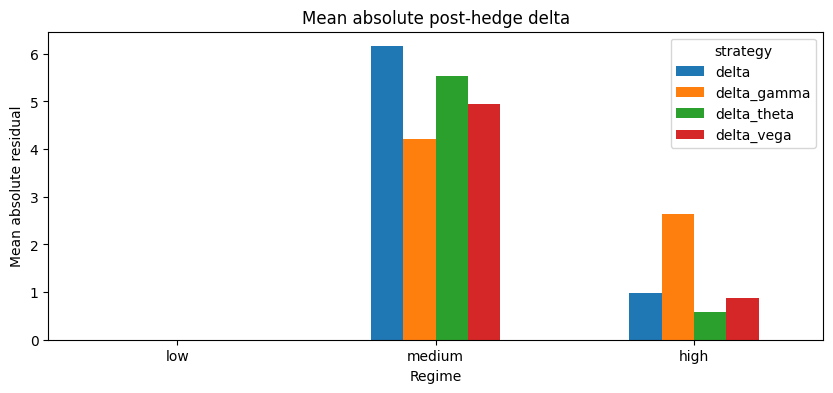

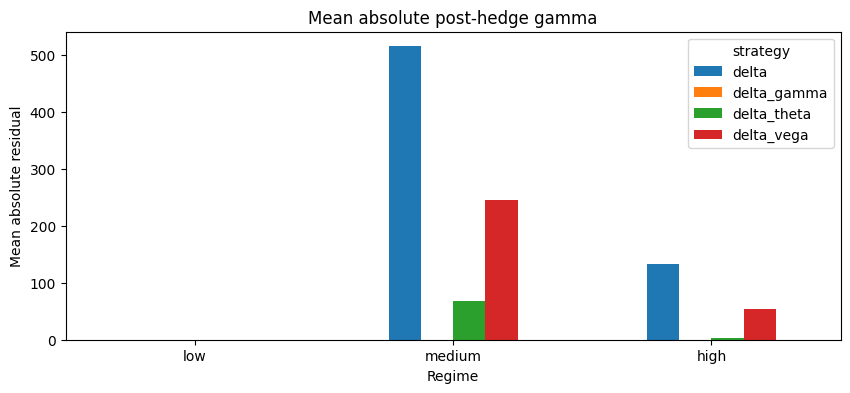

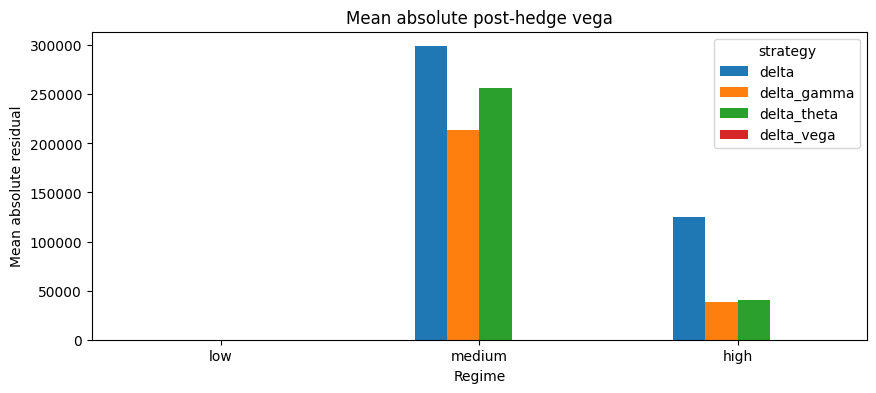

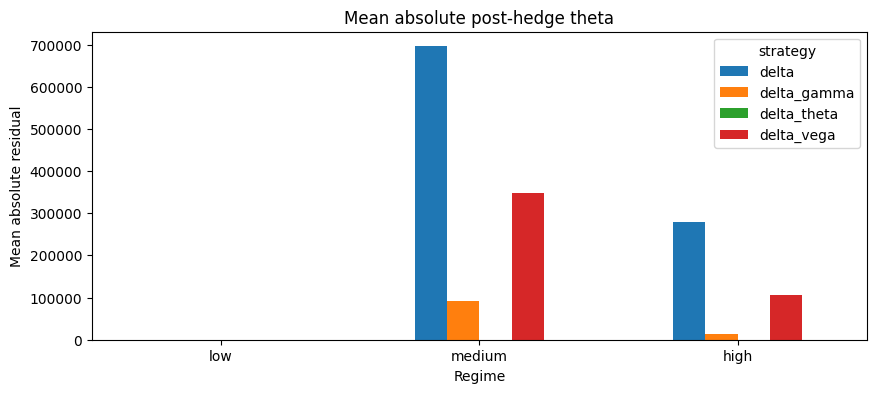

In [19]:
greeks_to_plot = [
    ("post_delta", "Mean absolute post-hedge delta"),
    ("post_gamma", "Mean absolute post-hedge gamma"),
    ("post_vega", "Mean absolute post-hedge vega"),
    ("post_theta", "Mean absolute post-hedge theta"),
]

for greek_col, title_text in greeks_to_plot:
    plot_df = (
        combined_history_df
        .groupby(["strategy", "regime"], as_index=False)[greek_col]
        .apply(lambda s: float(np.mean(np.abs(s))))
        .rename(columns={greek_col: "mean_abs_value"})
    )

    pivot_df = plot_df.pivot(index="regime", columns="strategy", values="mean_abs_value")
    pivot_df = pivot_df.reindex(index=["low", "medium", "high"])

    pivot_df.plot(kind="bar", figsize=(10, 4))
    plt.title(title_text)
    plt.xlabel("Regime")
    plt.ylabel("Mean absolute residual")
    plt.xticks(rotation=0)
    plt.show()


## 12. Optional: inspect one regime in more detail


In [20]:
chosen_regime = "high"

display(
    combined_history_df.loc[combined_history_df["regime"] == chosen_regime]
    .groupby("strategy", as_index=False)
    .agg(
        mean_abs_post_delta=("post_delta", lambda s: float(np.mean(np.abs(s)))),
        mean_abs_post_gamma=("post_gamma", lambda s: float(np.mean(np.abs(s)))),
        mean_abs_post_vega=("post_vega", lambda s: float(np.mean(np.abs(s)))),
        mean_abs_post_theta=("post_theta", lambda s: float(np.mean(np.abs(s)))),
        final_cash_outflow=("cumulative_cash_outflow_after_interest", "last"),
    )
)


,strategy,mean_abs_post_delta,mean_abs_post_gamma,mean_abs_post_vega,mean_abs_post_theta,final_cash_outflow
0,delta,0.972421,132.077513,124793.199877,279499.594333,-318617.681900
1,delta_gamma,2.646588,0.004770,38253.646207,12387.220224,-570866.128520
2,delta_theta,0.591904,3.106387,39993.305029,27.498758,-556478.187331
3,delta_vega,0.875783,53.084760,1.655955,105571.637728,-578942.786089


## 13. Where to add the DGV deep-dive cells later

The notebook is now ready for your newer DGV work.

### Recommended workflow
1. Add the DGV-specific helper cells **below this section**.
2. Define a solver with the same interface as the existing solvers:
   - inputs: `day_panel, base_contract_id, base_contracts, ...`
   - output: a dictionary with the same keys as the current solver outputs
3. Register it:
```python
STRATEGY_SOLVERS["delta_gamma_vega"] = solve_delta_gamma_vega
```
4. Re-run:
```python
strategies_to_compare = STRATEGIES_TO_RUN + ["delta_gamma_vega"]
combined_history_df, combined_trade_log_df = run_multiple_strategies(..., strategies_to_run=strategies_to_compare)
summary_df = summarise_results(combined_history_df)
```

That way the DGV strategy will automatically appear in:
- the daily tables
- the regime summary
- the side-by-side plots


# Delta-Gamma-Vega Hedging (Academic Prototype)

This section implements a **daily delta-gamma-vega (DGV) hedging framework** for a **short ATM option position sized against 100,000 shares of the underlying**.

### What this section contains
- imports market data and the synthetic option chain from `fetch_data_hedging.py`
- rebuilds a **persistent option panel** so the same contract can be repriced across dates
- starts on day 1 with a **short ATM call** sized to **100,000 underlying shares equivalent**
- hedges daily until the **base option expiry date**
- on the base expiry date:
  - settles the expiring base option at intrinsic value
  - closes any remaining hedge options at that day's theoretical value
  - flattens residual stock so the simulation ends with cash only
- builds a **daily strategy table** similar in spirit to your weekly delta-hedge table

### Academic scope
This is for **theoretical hedging** and academic demonstration. It is **not** a market execution or profit-maximization engine.


## 1. User inputs

You can change the ticker, sample length, entry maturity, hedge-bucket ranges, and stability settings here.

### Important interpretation used here
- Base position on day 1: **short ATM call**
- Size: **100,000 shares equivalent**
- Contract multiplier: **100 shares per option contract**
- Initial base option position: **-1,000 contracts**
- One hedge option is chosen from a **shorter DTE bucket**
- One hedge option is chosen from a **longer DTE bucket**
- The simulation stops on the **base option expiry date**


In [21]:
# ---------------------------------------------------
# Data and sample settings
# ---------------------------------------------------
TICKER = "AAPL"
MONTHS = 6
END_DATE = None                 # e.g. "2026-03-31"

# ---------------------------------------------------
# Base position settings
# ---------------------------------------------------
N_UNDERLYING_SHARES = 100_000
CONTRACT_MULTIPLIER = 100
BASE_OPTION_TYPE = "call"       # "call" or "put"
BASE_POSITION_SIGN = -1         # -1 = short, +1 = long
TARGET_ENTRY_DTE = 30

# ---------------------------------------------------
# Hedge settings
# ---------------------------------------------------
# SHORT_HEDGE_DTE_RANGE = (14, 21)
# LONG_HEDGE_DTE_RANGE = (45, 60)
# MAX_NEW_CANDIDATES_PER_BUCKET = 6
# CONDITION_NUMBER_LIMIT = 500

# Search around the clipped theoretical option hedge trade
OPTION_SEARCH_RADIUS = 2
STOCK_ROUND_LOT = 100

# Hard position / trade caps
MAX_ABS_OPTION_TRADE = 3000
MAX_ABS_STOCK_POSITION = 150_000
MAX_GROSS_OPTION_CONTRACTS = 5000

SHORT_HEDGE_DTE_RANGE = (7, 14)
LONG_HEDGE_DTE_RANGE = (60, 90)
MAX_NEW_CANDIDATES_PER_BUCKET = 12
CONDITION_NUMBER_LIMIT = 50000

# Loss weights for residual Greeks after actual trade selection
DELTA_WEIGHT = 1.0
GAMMA_WEIGHT = 1.0
VEGA_WEIGHT = 1.0

# Penalties to keep actual trades near theoretical trades and discourage inventory build-up
QUANTITY_PENALTY = 0.05
TURNOVER_PENALTY = 0.01
INVENTORY_PENALTY_WEIGHT = 0.02

# Synthetic IV settings (same logic as helper file)
SMILE_STRENGTH = 0.30
TERM_SLOPE = 0.08

# Cash carry / interest settings
TRADING_DAYS_PER_YEAR = 252
USE_DAILY_RISK_FREE_RATE_FOR_CASH = True
MANUAL_CASH_RATE = 0.05         # used only if the flag above is False

EPS = 1e-12

BASE_CONTRACTS = int(BASE_POSITION_SIGN * (N_UNDERLYING_SHARES / CONTRACT_MULTIPLIER))
print("Base option contracts on day 1:", BASE_CONTRACTS)


Base option contracts on day 1: -1000


## 2. Load the synthetic market dataset
This calls your helper module and pulls:
- stock history
- VIX history
- rates
- merged daily inputs
- synthetic option chain

In [22]:
dataset = build_synthetic_market_dataset(
    ticker=TICKER,
    months=MONTHS,
    end_date=END_DATE,
    expiry_days=(7, 14, 21, 30, 45, 60, 90, 120, 150, 180)
,
)

stock_df = dataset["stock_history"].copy()
vix_df = dataset["vix_history"].copy()
rates_df = dataset["risk_free_history"].copy()
merged_df = dataset["merged_daily_inputs"].copy()
raw_chain_df = dataset["synthetic_option_chain"].copy()

merged_df["date"] = pd.to_datetime(merged_df["date"])
raw_chain_df["trade_date"] = pd.to_datetime(raw_chain_df["trade_date"])
raw_chain_df["expiry"] = pd.to_datetime(raw_chain_df["expiry"])

print("Merged daily inputs shape:", merged_df.shape)
print("Raw synthetic chain shape:", raw_chain_df.shape)

display(merged_df.head())
display(raw_chain_df.head())

Merged daily inputs shape: (124, 11)
Raw synthetic chain shape: (33860, 19)


,date,open,high,low,close,volume,vix_close,risk_free_rate_pct,risk_free_rate,realized_vol_21d,base_iv
0,2025-10-08,256.519989,258.519989,256.109985,258.059998,36496900,16.299999,3.843,0.03843,NaN,0.1630
1,2025-10-09,257.809998,258.000000,253.139999,254.039993,38322000,16.430000,3.853,0.03853,NaN,0.1643
2,2025-10-10,254.940002,256.380005,244.000000,245.270004,61999100,21.660000,3.853,0.03853,NaN,0.2166
3,2025-10-13,249.380005,249.690002,245.559998,247.660004,38142900,19.030001,3.853,0.03853,NaN,0.1903
4,2025-10-14,246.600006,248.850006,244.699997,247.770004,35478000,20.809999,3.853,0.03853,NaN,0.2081


,trade_date,ticker,spot,expiry,dte,strike,option_type,risk_free_rate,vix_close,base_iv,synthetic_iv,theoretical_price,intrinsic_value,time_value,delta,gamma,vega,theta,rho
0,2025-10-08,AAPL,258.06,2025-10-15,7,200.0,call,0.03843,16.3,0.163,0.178350,58.207346,58.059998,0.147348,1.000000,0.000000,0.000000,-7.680337,3.832791
1,2025-10-08,AAPL,258.06,2025-10-15,7,210.0,call,0.03843,16.3,0.163,0.169643,48.214713,48.059998,0.154716,1.000000,0.000000,0.000000,-8.064354,4.024430
2,2025-10-08,AAPL,258.06,2025-10-15,7,220.0,call,0.03843,16.3,0.163,0.175254,38.222081,38.059998,0.162083,1.000000,0.000000,0.000000,-8.448371,4.216070
3,2025-10-08,AAPL,258.06,2025-10-15,7,230.0,call,0.03843,16.3,0.163,0.181860,28.229451,28.059998,0.169453,0.999998,0.000001,0.000342,-8.833990,4.407699
4,2025-10-08,AAPL,258.06,2025-10-15,7,240.0,call,0.03843,16.3,0.163,0.162232,18.237636,18.059998,0.177639,0.999469,0.000324,0.067182,-9.495257,4.596704


## 3. Rebuild a persistent option panel

The raw synthetic chain is generated independently for each date.  
For iterative rebalancing, we need the same contract to be repriced across later dates.

So we:
1. take the union of all contracts seen in the raw chain
2. create a stable `contract_id = expiry | strike | option_type`
3. reprice every live contract on every trade date using the same Black-Scholes helper functions

In [23]:
def synthetic_iv_from_inputs(spot, strike, time_to_expiry, base_iv, smile_strength=0.30, term_slope=0.08):
    if time_to_expiry <= 0:
        return np.nan

    log_moneyness = np.log(strike / spot)
    smile_adjustment = 1.0 + smile_strength * abs(log_moneyness)
    term_adjustment = 1.0 + term_slope * (np.sqrt(time_to_expiry) - np.sqrt(30 / 365.0))

    sigma = base_iv * smile_adjustment * term_adjustment
    sigma = float(np.clip(sigma, 0.05, 2.00))
    return sigma


def build_persistent_option_panel(merged_daily_inputs, raw_chain, smile_strength=0.30, term_slope=0.08):
    contract_master = (
        raw_chain[["expiry", "strike", "option_type"]]
        .drop_duplicates()
        .sort_values(["expiry", "option_type", "strike"])
        .reset_index(drop=True)
        .copy()
    )

    contract_master["contract_id"] = (
        contract_master["expiry"].dt.strftime("%Y-%m-%d")
        + "|"
        + contract_master["strike"].round(2).astype(str)
        + "|"
        + contract_master["option_type"]
    )

    rows = []

    daily_inputs = merged_daily_inputs.copy().sort_values("date")

    for _, day_row in daily_inputs.iterrows():
        trade_date = pd.Timestamp(day_row["date"])
        spot = float(day_row["close"])
        r = float(day_row["risk_free_rate"])
        base_iv = float(day_row["base_iv"])

        live_contracts = contract_master.loc[contract_master["expiry"] >= trade_date].copy()

        for _, c in live_contracts.iterrows():
            expiry = pd.Timestamp(c["expiry"])
            strike = float(c["strike"])
            option_type = c["option_type"]
            contract_id = c["contract_id"]

            dte_days = (expiry - trade_date).days
            T = dte_days / 365.0

            sigma = synthetic_iv_from_inputs(
                spot=spot,
                strike=strike,
                time_to_expiry=T,
                base_iv=base_iv,
                smile_strength=smile_strength,
                term_slope=term_slope,
            )

            price = black_scholes_price(spot, strike, T, r, sigma, option_type=option_type)
            delta, gamma, vega, theta, rho = black_scholes_greeks(
                spot, strike, T, r, sigma, option_type=option_type
            )

            rows.append(
                {
                    "trade_date": trade_date,
                    "contract_id": contract_id,
                    "expiry": expiry,
                    "dte": dte_days,
                    "strike": strike,
                    "option_type": option_type,
                    "spot": spot,
                    "risk_free_rate": r,
                    "base_iv": base_iv,
                    "synthetic_iv": sigma,
                    "theoretical_price": price,
                    "delta": delta,
                    "gamma": gamma,
                    "vega": vega,
                    "theta": theta,
                    "rho": rho,
                }
            )

    panel = (
        pd.DataFrame(rows)
        .sort_values(["trade_date", "expiry", "option_type", "strike"])
        .reset_index(drop=True)
    )
    return panel


panel_df = build_persistent_option_panel(
    merged_daily_inputs=merged_df,
    raw_chain=raw_chain_df,
    smile_strength=SMILE_STRENGTH,
    term_slope=TERM_SLOPE,
)

print("Persistent option panel shape:", panel_df.shape)
display(panel_df.head())


Persistent option panel shape: (1161222, 16)


,trade_date,contract_id,expiry,dte,strike,option_type,spot,risk_free_rate,base_iv,synthetic_iv,theoretical_price,delta,gamma,vega,theta,rho
0,2025-10-08,2025-10-15|200.0|call,2025-10-15,7,200.0,call,258.059998,0.03843,0.163,0.173383,58.207346,1.000000,1.393238e-26,3.085164e-24,-7.680337,3.832791
1,2025-10-08,2025-10-15|210.0|call,2025-10-15,7,210.0,call,258.059998,0.03843,0.163,0.171025,48.214713,1.000000,1.626832e-18,3.553449e-16,-8.064354,4.024430
2,2025-10-08,2025-10-15|220.0|call,2025-10-15,7,220.0,call,258.059998,0.03843,0.163,0.168778,38.222081,1.000000,3.729482e-12,8.039143e-10,-8.448371,4.216070
3,2025-10-08,2025-10-15|230.0|call,2025-10-15,7,230.0,call,258.059998,0.03843,0.163,0.166630,28.229449,1.000000,2.126799e-07,4.526111e-05,-8.832582,4.407708
4,2025-10-08,2025-10-15|240.0|call,2025-10-15,7,240.0,call,258.059998,0.03843,0.163,0.164573,18.237806,0.999375,3.714789e-04,7.807999e-02,-9.545182,4.596236


## 4. Helper functions

These helpers:
- choose the day-1 ATM base contract
- compute portfolio Greeks using option contracts and stock shares
- build a daily hedge universe from:
  - currently held hedge contracts
  - fresh short-dated candidates
  - fresh longer-dated candidates
- solve the continuous theoretical DGV hedge
- convert it into an actual discrete trade under conditioning and inventory caps


In [26]:
def choose_initial_atm_contract(day_panel, target_dte=30, option_type="call"):
    df = day_panel.loc[day_panel["option_type"] == option_type].copy()
    df["atm_distance"] = (df["strike"] - df["spot"]).abs()
    df["dte_distance"] = (df["dte"] - target_dte).abs()

    chosen = (
        df.sort_values(["atm_distance", "dte_distance", "expiry", "strike"])
        .iloc[0]
    )
    return chosen


def clean_position_book(position_book, day_panel):
    live_ids = set(day_panel["contract_id"].unique())
    cleaned = {
        cid: qty
        for cid, qty in position_book.items()
        if (cid in live_ids) and (abs(qty) > EPS)
    }
    return cleaned


def round_to_lot(x, lot_size=100):
    if not np.isfinite(x):
        return 0.0
    return float(np.round(x / lot_size) * lot_size)


def portfolio_snapshot(day_panel, option_positions, stock_position=0.0, contract_multiplier=100):
    df = day_panel.set_index("contract_id")

    rows = []
    total_delta = float(stock_position)
    total_gamma = 0.0
    total_vega = 0.0
    total_option_value = 0.0

    for cid, qty_contracts in option_positions.items():
        if cid not in df.index:
            continue

        row = df.loc[cid]
        qty_shares_equiv = qty_contracts * contract_multiplier

        pos_delta = qty_shares_equiv * float(row["delta"])
        pos_gamma = qty_shares_equiv * float(row["gamma"])
        pos_vega = qty_shares_equiv * float(row["vega"])
        pos_value = qty_shares_equiv * float(row["theoretical_price"])

        rows.append(
            {
                "contract_id": cid,
                "quantity_contracts": qty_contracts,
                "quantity_shares_equiv": qty_shares_equiv,
                "price_per_share": float(row["theoretical_price"]),
                "delta_per_share": float(row["delta"]),
                "gamma_per_share": float(row["gamma"]),
                "vega_per_share": float(row["vega"]),
                "position_delta": pos_delta,
                "position_gamma": pos_gamma,
                "position_vega": pos_vega,
                "position_value": pos_value,
            }
        )

        total_delta += pos_delta
        total_gamma += pos_gamma
        total_vega += pos_vega
        total_option_value += pos_value

    details = pd.DataFrame(rows)

    summary = {
        "stock_position_shares": float(stock_position),
        "option_value": float(total_option_value),
        "total_delta": float(total_delta),
        "total_gamma": float(total_gamma),
        "total_vega": float(total_vega),
    }
    return summary, details


def select_current_hedge_candidates(
    day_panel,
    option_positions,
    exclude_contract_ids=None,
    short_long_split_dte=30,
):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    held_ids = [
        cid
        for cid, qty in option_positions.items()
        if (abs(qty) > EPS) and (cid not in exclude_contract_ids)
    ]

    if not held_ids:
        return pd.DataFrame(), pd.DataFrame()

    held = day_panel.loc[day_panel["contract_id"].isin(held_ids)].copy()
    if len(held) == 0:
        return pd.DataFrame(), pd.DataFrame()

    held = held.replace([np.inf, -np.inf], np.nan)
    held = held.dropna(subset=[col for col in ["dte", "gamma", "vega", "delta", "theoretical_price"] if col in held.columns])
    if len(held) == 0:
        return pd.DataFrame(), pd.DataFrame()

    held["candidate_score"] = -1.0

    short_candidates = held.loc[held["dte"] <= short_long_split_dte].copy()
    long_candidates = held.loc[held["dte"] > short_long_split_dte].copy()

    return short_candidates.reset_index(drop=True), long_candidates.reset_index(drop=True)


def select_bucket_candidates(day_panel, dte_range, max_candidates=6, exclude_contract_ids=None):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    lower_dte, upper_dte = dte_range

    df = day_panel.copy()
    df = df.loc[~df["contract_id"].isin(exclude_contract_ids)].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[col for col in ["dte", "strike", "spot", "gamma", "vega", "delta", "theoretical_price"] if col in df.columns])
    df = df.loc[df["dte"].between(lower_dte, upper_dte)].copy()
    df = df.loc[(df["gamma"].abs() > 1e-12) & (df["vega"].abs() > 1e-12)].copy()

    if len(df) == 0:
        return df.reset_index(drop=True)

    target_dte = 0.5 * (lower_dte + upper_dte)
    df["atm_score"] = np.abs(np.log(df["strike"] / df["spot"]))
    df["dte_score"] = np.abs(df["dte"] - target_dte) / 365.0
    df["candidate_score"] = df["atm_score"] + 0.50 * df["dte_score"]

    return (
        df.sort_values(["candidate_score", "expiry", "option_type", "strike"])
        .head(max_candidates)
        .reset_index(drop=True)
    )


def combine_candidate_frames(*frames):
    usable_frames = [frame.copy() for frame in frames if frame is not None and len(frame) > 0]
    if not usable_frames:
        return pd.DataFrame()

    combined = pd.concat(usable_frames, ignore_index=True)
    if "candidate_score" not in combined.columns:
        combined["candidate_score"] = 0.0
    combined["candidate_score"] = combined["candidate_score"].fillna(-1.0)
    combined = combined.replace([np.inf, -np.inf], np.nan)
    combined = combined.dropna(subset=[col for col in ["gamma", "vega", "delta", "theoretical_price", "candidate_score"] if col in combined.columns])

    if len(combined) == 0:
        return combined.reset_index(drop=True)

    return (
        combined
        .drop_duplicates(subset=["contract_id"], keep="first")
        .sort_values(["candidate_score", "expiry", "option_type", "strike"])
        .reset_index(drop=True)
    )


def apply_option_trades(option_positions, option_trade_map):
    updated = {
        cid: float(qty)
        for cid, qty in option_positions.items()
        if abs(qty) > EPS
    }

    for cid, trade_qty in option_trade_map.items():
        updated[cid] = updated.get(cid, 0.0) + float(trade_qty)

    return {
        cid: qty
        for cid, qty in updated.items()
        if abs(qty) > EPS
    }


def gross_option_contracts(option_positions):
    return float(sum(abs(qty) for qty in option_positions.values()))


def hedge_objective(
    residual_delta,
    residual_gamma,
    residual_vega,
    delta_scale,
    gamma_scale,
    vega_scale,
    q_a_actual,
    q_b_actual,
    q_stock_actual,
    q_a_theory,
    q_b_theory,
    q_stock_theory,
    post_option_positions,
    post_stock_position,
    quantity_penalty=0.05,
    turnover_penalty=0.01,
    inventory_penalty_weight=0.02,
):
    greek_loss = (
        DELTA_WEIGHT * (residual_delta / max(delta_scale, 1.0)) ** 2
        + GAMMA_WEIGHT * (residual_gamma / max(gamma_scale, 1e-8)) ** 2
        + VEGA_WEIGHT * (residual_vega / max(vega_scale, 1e-8)) ** 2
    )

    quantity_gap = (
        (q_a_actual - q_a_theory) ** 2
        + (q_b_actual - q_b_theory) ** 2
        + ((q_stock_actual - q_stock_theory) / max(STOCK_ROUND_LOT, 1.0)) ** 2
    )

    turnover = (
        abs(q_a_actual)
        + abs(q_b_actual)
        + abs(q_stock_actual) / max(STOCK_ROUND_LOT, 1.0)
    )

    inventory_penalty = (
        abs(post_stock_position) / max(STOCK_ROUND_LOT, 1.0)
        + sum(abs(qty) for qty in post_option_positions.values())
    )

    return (
        greek_loss
        + quantity_penalty * quantity_gap
        + turnover_penalty * turnover
        + inventory_penalty_weight * inventory_penalty
    )


def find_best_daily_rebalance(
    day_panel,
    option_positions,
    stock_position,
    exclude_contract_ids=None,
    max_new_candidates_per_bucket=6,
    short_dte_range=(14, 21),
    long_dte_range=(45, 60),
    option_search_radius=2,
    condition_number_limit=500,
    quantity_penalty=0.05,
    turnover_penalty=0.01,
    inventory_penalty_weight=0.02,
    max_abs_option_trade=3000,
    max_abs_stock_position=150_000,
    max_gross_option_contracts=5000,
    contract_multiplier=100,
):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    pre_summary, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=contract_multiplier,
    )

    short_long_split_dte = 0.5 * (short_dte_range[1] + long_dte_range[0])

    current_short_candidates, current_long_candidates = select_current_hedge_candidates(
        day_panel=day_panel,
        option_positions=option_positions,
        exclude_contract_ids=exclude_contract_ids,
        short_long_split_dte=short_long_split_dte,
    )

    fresh_short_candidates = select_bucket_candidates(
        day_panel=day_panel,
        dte_range=short_dte_range,
        max_candidates=max_new_candidates_per_bucket,
        exclude_contract_ids=exclude_contract_ids,
    )
    fresh_long_candidates = select_bucket_candidates(
        day_panel=day_panel,
        dte_range=long_dte_range,
        max_candidates=max_new_candidates_per_bucket,
        exclude_contract_ids=exclude_contract_ids,
    )

    short_candidates = combine_candidate_frames(current_short_candidates, fresh_short_candidates)
    long_candidates = combine_candidate_frames(current_long_candidates, fresh_long_candidates)

    if (len(short_candidates) == 0) or (len(long_candidates) == 0):
        return None

    best = None
    short_rows = list(short_candidates.to_dict("records"))
    long_rows = list(long_candidates.to_dict("records"))

    delta_scale = max(abs(pre_summary["total_delta"]), N_UNDERLYING_SHARES, 1.0)
    gamma_scale = max(abs(pre_summary["total_gamma"]), 1.0)
    vega_scale = max(abs(pre_summary["total_vega"]), 1.0)

    for row_a in short_rows:
        for row_b in long_rows:
            if row_a["contract_id"] == row_b["contract_id"]:
                continue

            A = np.array(
                [
                    [contract_multiplier * row_a["gamma"], contract_multiplier * row_b["gamma"]],
                    [contract_multiplier * row_a["vega"], contract_multiplier * row_b["vega"]],
                ],
                dtype=float,
            )

            if not np.all(np.isfinite(A)):
                continue

            try:
                cond_number = np.linalg.cond(A)
            except np.linalg.LinAlgError:
                continue
            if (not np.isfinite(cond_number)) or (cond_number > condition_number_limit):
                continue

            b = -np.array(
                [pre_summary["total_gamma"], pre_summary["total_vega"]],
                dtype=float,
            )

            try:
                q_theory = np.linalg.solve(A, b)
            except np.linalg.LinAlgError:
                continue
            if not np.all(np.isfinite(q_theory)):
                continue

            q_a_theory = float(np.clip(q_theory[0], -max_abs_option_trade, max_abs_option_trade))
            q_b_theory = float(np.clip(q_theory[1], -max_abs_option_trade, max_abs_option_trade))

            q_stock_theory = -(
                pre_summary["total_delta"]
                + contract_multiplier * row_a["delta"] * q_a_theory
                + contract_multiplier * row_b["delta"] * q_b_theory
            )
            post_stock_theory = float(
                np.clip(stock_position + q_stock_theory, -max_abs_stock_position, max_abs_stock_position)
            )
            q_stock_theory = float(post_stock_theory - stock_position)
            if not all(np.isfinite(v) for v in [q_a_theory, q_b_theory, q_stock_theory]):
                continue

            q_a_center = int(np.round(q_a_theory))
            q_b_center = int(np.round(q_b_theory))

            q_a_min = max(-max_abs_option_trade, q_a_center - option_search_radius)
            q_a_max = min(max_abs_option_trade, q_a_center + option_search_radius)
            q_b_min = max(-max_abs_option_trade, q_b_center - option_search_radius)
            q_b_max = min(max_abs_option_trade, q_b_center + option_search_radius)

            q_a_grid = range(q_a_min, q_a_max + 1)
            q_b_grid = range(q_b_min, q_b_max + 1)

            for q_a_actual in q_a_grid:
                for q_b_actual in q_b_grid:
                    raw_stock_trade = -(
                        pre_summary["total_delta"]
                        + contract_multiplier * row_a["delta"] * q_a_actual
                        + contract_multiplier * row_b["delta"] * q_b_actual
                    )
                    post_stock_position = round_to_lot(
                        np.clip(
                            stock_position + raw_stock_trade,
                            -max_abs_stock_position,
                            max_abs_stock_position,
                        ),
                        lot_size=STOCK_ROUND_LOT,
                    )
                    post_stock_position = float(
                        np.clip(post_stock_position, -max_abs_stock_position, max_abs_stock_position)
                    )
                    q_stock_actual = float(post_stock_position - stock_position)

                    post_option_positions = apply_option_trades(
                        option_positions,
                        {
                            row_a["contract_id"]: float(q_a_actual),
                            row_b["contract_id"]: float(q_b_actual),
                        },
                    )
                    gross_contracts = gross_option_contracts(post_option_positions)
                    if gross_contracts > max_gross_option_contracts:
                        continue

                    residual_delta = (
                        pre_summary["total_delta"]
                        + contract_multiplier * row_a["delta"] * q_a_actual
                        + contract_multiplier * row_b["delta"] * q_b_actual
                        + q_stock_actual
                    )
                    residual_gamma = (
                        pre_summary["total_gamma"]
                        + contract_multiplier * row_a["gamma"] * q_a_actual
                        + contract_multiplier * row_b["gamma"] * q_b_actual
                    )
                    residual_vega = (
                        pre_summary["total_vega"]
                        + contract_multiplier * row_a["vega"] * q_a_actual
                        + contract_multiplier * row_b["vega"] * q_b_actual
                    )
                    if not all(np.isfinite(v) for v in [residual_delta, residual_gamma, residual_vega, post_stock_position]):
                        continue

                    objective = hedge_objective(
                        residual_delta=residual_delta,
                        residual_gamma=residual_gamma,
                        residual_vega=residual_vega,
                        delta_scale=delta_scale,
                        gamma_scale=gamma_scale,
                        vega_scale=vega_scale,
                        q_a_actual=q_a_actual,
                        q_b_actual=q_b_actual,
                        q_stock_actual=q_stock_actual,
                        q_a_theory=q_a_theory,
                        q_b_theory=q_b_theory,
                        q_stock_theory=q_stock_theory,
                        post_option_positions=post_option_positions,
                        post_stock_position=post_stock_position,
                        quantity_penalty=quantity_penalty,
                        turnover_penalty=turnover_penalty,
                        inventory_penalty_weight=inventory_penalty_weight,
                    )
                    if not np.isfinite(objective):
                        continue

                    candidate = {
                        "contract_a": row_a["contract_id"],
                        "contract_b": row_b["contract_id"],
                        "row_a": row_a,
                        "row_b": row_b,
                        "q_a_theory": q_a_theory,
                        "q_b_theory": q_b_theory,
                        "q_stock_theory": float(q_stock_theory),
                        "q_a_actual": float(q_a_actual),
                        "q_b_actual": float(q_b_actual),
                        "q_stock_actual": float(q_stock_actual),
                        "post_stock_position": float(post_stock_position),
                        "post_option_positions": post_option_positions,
                        "gross_option_contracts_after_trade": float(gross_contracts),
                        "post_delta_residual": float(residual_delta),
                        "post_gamma_residual": float(residual_gamma),
                        "post_vega_residual": float(residual_vega),
                        "condition_number": float(cond_number),
                        "objective": float(objective),
                    }

                    if (best is None) or (candidate["objective"] < best["objective"]):
                        best = candidate

    return best


## 5. Run the daily DGV hedging simulation

### Base book on day 1
We start with a **short ATM call** whose total underlying equivalent is **100,000 shares**.

### Horizon and roll convention
- rebalance through the **latest available trade date** in the dataset
- when the current base option reaches expiry, liquidate the existing book, open a fresh ATM base contract, and continue hedging on the same day
- the final row therefore shows the live hedged book on the most recent trade date rather than stopping at the first base expiry

### Rebalancing logic
On each trade date:
1. liquidate and roll the base book if the active cycle has expired
2. value the carried actual book after any new base entry
3. build a hedge universe from:
   - currently held hedge contracts
   - fresh short-dated candidates
   - fresh longer-dated candidates
4. solve the **continuous theoretical DGV-neutral hedge**
5. convert it into **capped discrete trades**
6. apply the trades and record the daily table


In [27]:
all_dates = [pd.Timestamp(trade_date) for trade_date in sorted(panel_df["trade_date"].unique())]
first_date = all_dates[0]

day1_panel = panel_df.loc[panel_df["trade_date"] == first_date].copy()

preview_contract = choose_initial_atm_contract(
    day_panel=day1_panel,
    target_dte=TARGET_ENTRY_DTE,
    option_type=BASE_OPTION_TYPE,
)

print("Chosen base contract on day 1:")
display(
    preview_contract.to_frame().T[
        [
            "trade_date", "expiry", "dte", "strike", "option_type",
            "contract_id", "theoretical_price", "delta", "gamma", "vega"
        ]
    ]
)
print("Simulation rebalances through latest available trade date:", all_dates[-1].date())

current_base_contract_id = None
current_base_expiry = None
base_cycle_index = 0

# Position book stores quantities in option contracts
option_positions = {}
stock_position = 0.0

cumulative_cash_after_interest = 0.0

history_rows = []
trade_log_rows = []

for trade_date in all_dates:
    day_panel = panel_df.loc[panel_df["trade_date"] == trade_date].copy()
    active_contract_ids = set(day_panel["contract_id"])
    spot_t = float(day_panel["spot"].iloc[0])
    r_cash_t = float(day_panel["risk_free_rate"].iloc[0]) if USE_DAILY_RISK_FREE_RATE_FOR_CASH else MANUAL_CASH_RATE

    option_positions = clean_position_book(option_positions, day_panel)

    base_trade_contracts = 0.0
    base_trade_cashflow = 0.0
    hedge_option_trade_cashflow = 0.0
    stock_trade_cashflow = 0.0
    option_liquidation_cashflow = 0.0
    stock_liquidation_cashflow = 0.0
    liquidation_applied = False
    is_base_entry_day = False

    q_a_actual = 0.0
    q_b_actual = 0.0
    q_stock_actual = 0.0
    q_a_theory = np.nan
    q_b_theory = np.nan
    q_stock_theory = np.nan
    contract_a = None
    contract_b = None
    condition_number = np.nan
    objective = np.nan
    gross_option_contracts_after_trade = gross_option_contracts(option_positions)

    is_base_expiry_day = (
        current_base_contract_id is not None
        and (
            trade_date >= current_base_expiry
            or current_base_contract_id not in active_contract_ids
        )
    )

    if is_base_expiry_day:
        liquidation_applied = True

        for cid, qty in list(option_positions.items()):
            if cid not in active_contract_ids:
                continue
            row = day_panel.loc[day_panel["contract_id"] == cid].iloc[0]
            option_liquidation_cashflow += (-qty) * CONTRACT_MULTIPLIER * float(row["theoretical_price"])

        stock_liquidation_cashflow = (-stock_position) * spot_t
        option_positions = {}
        stock_position = 0.0
        gross_option_contracts_after_trade = 0.0

    if current_base_contract_id is None or liquidation_applied:
        entry_contract = choose_initial_atm_contract(
            day_panel=day_panel,
            target_dte=TARGET_ENTRY_DTE,
            option_type=BASE_OPTION_TYPE,
        )

        current_base_contract_id = entry_contract["contract_id"]
        current_base_expiry = pd.Timestamp(entry_contract["expiry"])
        base_cycle_index += 1

        option_positions = {current_base_contract_id: float(BASE_CONTRACTS)}
        base_trade_contracts = float(BASE_CONTRACTS)
        base_trade_cashflow = base_trade_contracts * CONTRACT_MULTIPLIER * float(entry_contract["theoretical_price"])
        is_base_entry_day = True

    base_row = day_panel.loc[day_panel["contract_id"] == current_base_contract_id].iloc[0]

    pre_summary, pre_details = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    rebalance = find_best_daily_rebalance(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        exclude_contract_ids={current_base_contract_id},
        max_new_candidates_per_bucket=MAX_NEW_CANDIDATES_PER_BUCKET,
        short_dte_range=SHORT_HEDGE_DTE_RANGE,
        long_dte_range=LONG_HEDGE_DTE_RANGE,
        option_search_radius=OPTION_SEARCH_RADIUS,
        condition_number_limit=CONDITION_NUMBER_LIMIT,
        quantity_penalty=QUANTITY_PENALTY,
        turnover_penalty=TURNOVER_PENALTY,
        inventory_penalty_weight=INVENTORY_PENALTY_WEIGHT,
        max_abs_option_trade=MAX_ABS_OPTION_TRADE,
        max_abs_stock_position=MAX_ABS_STOCK_POSITION,
        max_gross_option_contracts=MAX_GROSS_OPTION_CONTRACTS,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    if rebalance is not None:
        contract_a = rebalance["contract_a"]
        contract_b = rebalance["contract_b"]

        q_a_theory = rebalance["q_a_theory"]
        q_b_theory = rebalance["q_b_theory"]
        q_stock_theory = rebalance["q_stock_theory"]

        q_a_actual = rebalance["q_a_actual"]
        q_b_actual = rebalance["q_b_actual"]
        q_stock_actual = rebalance["q_stock_actual"]

        condition_number = rebalance["condition_number"]
        objective = rebalance["objective"]

        row_a = day_panel.loc[day_panel["contract_id"] == contract_a].iloc[0]
        row_b = day_panel.loc[day_panel["contract_id"] == contract_b].iloc[0]

        hedge_option_trade_cashflow = (
            q_a_actual * CONTRACT_MULTIPLIER * float(row_a["theoretical_price"])
            + q_b_actual * CONTRACT_MULTIPLIER * float(row_b["theoretical_price"])
        )
        stock_trade_cashflow = q_stock_actual * spot_t

        option_positions = apply_option_trades(
            option_positions,
            {
                contract_a: q_a_actual,
                contract_b: q_b_actual,
            },
        )
        stock_position = float(rebalance["post_stock_position"])
        gross_option_contracts_after_trade = gross_option_contracts(option_positions)

    total_trade_cashflow = (
        base_trade_cashflow
        + hedge_option_trade_cashflow
        + stock_trade_cashflow
        + option_liquidation_cashflow
        + stock_liquidation_cashflow
    )
    cumulative_cash_before_interest = cumulative_cash_after_interest + total_trade_cashflow
    interest_cost = cumulative_cash_before_interest * (r_cash_t / TRADING_DAYS_PER_YEAR)
    cumulative_cash_after_interest = cumulative_cash_before_interest + interest_cost

    post_summary, post_details = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    history_rows.append(
        {
            "trade_date": trade_date,
            "spot": spot_t,
            "risk_free_rate": r_cash_t,
            "base_cycle_index": int(base_cycle_index),
            "is_base_entry_day": bool(is_base_entry_day),
            "is_base_expiry_day": bool(is_base_expiry_day),
            "liquidation_applied": bool(liquidation_applied),

            "base_contract_id": current_base_contract_id,
            "base_expiry": current_base_expiry.date(),
            "base_dte": float(base_row["dte"]),
            "base_strike": float(base_row["strike"]),
            "base_option_type": BASE_OPTION_TYPE,
            "base_option_price_per_share": float(base_row["theoretical_price"]),
            "base_delta_per_share": float(base_row["delta"]),
            "base_gamma_per_share": float(base_row["gamma"]),
            "base_vega_per_share": float(base_row["vega"]),
            "base_contracts_held": float(option_positions.get(current_base_contract_id, 0.0)),

            "pre_delta": float(pre_summary["total_delta"]),
            "pre_gamma": float(pre_summary["total_gamma"]),
            "pre_vega": float(pre_summary["total_vega"]),

            "contract_a": contract_a,
            "contract_b": contract_b,
            "q_a_theory_contracts": q_a_theory,
            "q_b_theory_contracts": q_b_theory,
            "q_stock_theory_shares": q_stock_theory,
            "q_a_actual_contracts": q_a_actual,
            "q_b_actual_contracts": q_b_actual,
            "q_stock_actual_shares": q_stock_actual,

            "post_delta": float(post_summary["total_delta"]),
            "post_gamma": float(post_summary["total_gamma"]),
            "post_vega": float(post_summary["total_vega"]),

            "stock_position_after_trade": float(stock_position),
            "gross_option_contracts_after_trade": float(gross_option_contracts_after_trade),
            "n_option_positions_after_trade": int(len(option_positions)),

            "base_trade_cashflow": float(base_trade_cashflow),
            "hedge_option_trade_cashflow": float(hedge_option_trade_cashflow),
            "stock_trade_cashflow": float(stock_trade_cashflow),
            "option_liquidation_cashflow": float(option_liquidation_cashflow),
            "stock_liquidation_cashflow": float(stock_liquidation_cashflow),
            "total_trade_cashflow": float(total_trade_cashflow),
            "cumulative_cash_outflow_before_interest": float(cumulative_cash_before_interest),
            "interest_cost": float(interest_cost),
            "cumulative_cash_outflow_after_interest": float(cumulative_cash_after_interest),

            "base_trade_cashflow_k": float(base_trade_cashflow / 1000.0),
            "hedge_option_trade_cashflow_k": float(hedge_option_trade_cashflow / 1000.0),
            "stock_trade_cashflow_k": float(stock_trade_cashflow / 1000.0),
            "option_liquidation_cashflow_k": float(option_liquidation_cashflow / 1000.0),
            "stock_liquidation_cashflow_k": float(stock_liquidation_cashflow / 1000.0),
            "total_trade_cashflow_k": float(total_trade_cashflow / 1000.0),
            "cumulative_cash_outflow_before_interest_k": float(cumulative_cash_before_interest / 1000.0),
            "interest_cost_k": float(interest_cost / 1000.0),
            "cumulative_cash_outflow_after_interest_k": float(cumulative_cash_after_interest / 1000.0),

            "objective": objective,
            "condition_number": condition_number,
        }
    )

    trade_log_rows.append(
        {
            "trade_date": trade_date,
            "base_cycle_index": int(base_cycle_index),
            "is_base_entry_day": bool(is_base_entry_day),
            "is_base_expiry_day": bool(is_base_expiry_day),
            "liquidation_applied": bool(liquidation_applied),
            "base_trade_contracts": base_trade_contracts,
            "contract_a": contract_a,
            "contract_b": contract_b,
            "q_a_theory_contracts": q_a_theory,
            "q_b_theory_contracts": q_b_theory,
            "q_stock_theory_shares": q_stock_theory,
            "q_a_actual_contracts": q_a_actual,
            "q_b_actual_contracts": q_b_actual,
            "q_stock_actual_shares": q_stock_actual,
            "base_trade_cashflow": base_trade_cashflow,
            "hedge_option_trade_cashflow": hedge_option_trade_cashflow,
            "stock_trade_cashflow": stock_trade_cashflow,
            "option_liquidation_cashflow": option_liquidation_cashflow,
            "stock_liquidation_cashflow": stock_liquidation_cashflow,
            "total_trade_cashflow": total_trade_cashflow,
            "post_delta": post_summary["total_delta"],
            "post_gamma": post_summary["total_gamma"],
            "post_vega": post_summary["total_vega"],
            "gross_option_contracts_after_trade": gross_option_contracts_after_trade,
            "stock_position_after_trade": stock_position,
        }
    )

history_df = pd.DataFrame(history_rows)
trade_log_df = pd.DataFrame(trade_log_rows)

print("Simulation finished.")
print("Simulation end date:", all_dates[-1].date())
print("Base cycles entered:", base_cycle_index)
print("Rows in daily history:", len(history_df))
display(history_df.head())


Chosen base contract on day 1:


,trade_date,expiry,dte,strike,option_type,contract_id,theoretical_price,delta,gamma,vega
762,2025-10-08 00:00:00,2025-11-07 00:00:00,30,260.0,call,2025-11-07|260.0|call,4.292413,0.472474,0.032929,29.444864


Simulation rebalances through latest available trade date: 2026-04-07
Simulation finished.
Simulation end date: 2026-04-07
Base cycles entered: 6
Rows in daily history: 124


,trade_date,spot,risk_free_rate,base_cycle_index,is_base_entry_day,is_base_expiry_day,liquidation_applied,base_contract_id,base_expiry,base_dte,base_strike,base_option_type,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_contracts_held,pre_delta,pre_gamma,pre_vega,contract_a,contract_b,q_a_theory_contracts,q_b_theory_contracts,q_stock_theory_shares,q_a_actual_contracts,q_b_actual_contracts,q_stock_actual_shares,post_delta,post_gamma,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,n_option_positions_after_trade,base_trade_cashflow,hedge_option_trade_cashflow,stock_trade_cashflow,option_liquidation_cashflow,stock_liquidation_cashflow,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest,base_trade_cashflow_k,hedge_option_trade_cashflow_k,stock_trade_cashflow_k,option_liquidation_cashflow_k,stock_liquidation_cashflow_k,total_trade_cashflow_k,cumulative_cash_outflow_before_interest_k,interest_cost_k,cumulative_cash_outflow_after_interest_k,objective,condition_number
0,2025-10-08,258.059998,0.03843,1,True,False,False,2025-11-07|260.0|call,2025-11-07,30.0,260.0,call,4.292413,0.472474,0.032929,29.444864,-1000.0,-47247.402167,-3292.892029,-2.944486e+06,2025-10-15|260.0|call,2025-12-24|260.0|call,335.588064,526.269218,7025.860933,336.0,526.0,7000.0,-23.934175,2.184094,-708.682246,7000.0,1862.0,3,-429241.262558,467647.843501,1.806420e+06,0.0,0.0,1.844827e+06,1.844827e+06,281.336046,1.845108e+06,-429.241263,467.647844,1806.419983,0.0,0.0,1844.826564,1844.826564,0.281336,1845.107900,47.975453,847.312577
1,2025-10-09,254.039993,0.03853,1,False,False,False,2025-11-07|260.0|call,2025-11-07,29.0,260.0,call,2.627328,0.341457,0.030991,26.280318,-1000.0,619.432816,-606.788609,2.078012e+04,2025-10-17|255.0|call,2025-12-24|260.0|call,105.838558,-39.123994,-3742.263561,106.0,-39.0,-3800.0,-44.956511,1.297733,806.912531,3200.0,1929.0,4,0.000000,-1341.597145,-9.653520e+05,0.0,0.0,-9.666936e+05,8.784143e+05,134.306760,8.785486e+05,0.000000,-1.341597,-965.351974,0.0,0.0,-966.693572,878.414328,0.134307,878.548635,41.070252,868.168072
2,2025-10-10,245.270004,0.03853,1,False,False,False,2025-11-07|260.0|call,2025-11-07,28.0,260.0,call,1.522411,0.190179,0.018150,18.445153,-1000.0,1629.811510,-678.727191,2.050786e+05,2025-10-17|245.0|call,2025-12-24|260.0|call,151.201647,-102.002552,-6314.388922,151.0,-102.0,-6300.0,3.772116,-1.099223,-262.195700,-3100.0,1978.0,5,0.000000,-4251.904760,-1.545201e+06,0.0,0.0,-1.549453e+06,-6.709043e+05,-102.579135,-6.710069e+05,0.000000,-4.251905,-1545.201027,0.0,0.0,-1549.452932,-670.904297,-0.102579,-671.006876,43.343073,897.165715
3,2025-10-13,247.660004,0.03853,1,False,False,False,2025-11-07|260.0|call,2025-11-07,25.0,260.0,call,1.255529,0.187628,0.021560,17.453069,-1000.0,2648.321941,-145.968205,-3.302969e+04,2025-10-23|250.0|put,2025-12-24|260.0|call,30.558982,-3.846063,-688.830254,30.0,-4.0,-700.0,17.182983,-3.049533,-1501.859908,-3800.0,2004.0,6,0.000000,10942.748035,-1.733620e+05,0.0,0.0,-1.624193e+05,-8.334261e+05,-127.428207,-8.335536e+05,0.000000,10.942748,-173.362003,0.0,0.0,-162.419255,-833.426130,-0.127428,-833.553559,41.269936,1071.771335
4,2025-10-14,247.770004,0.03853,1,False,False,False,2025-11-07|260.0|call,2025-11-07,24.0,260.0,call,1.517868,0.206597,0.021333,18.135032,-1000.0,-1084.757242,-21.632563,-8.413580e+04,2025-10-17|255.0|call,2025-12-28|250.0|put,-3.748402,19.030551,2032.761355,-4.0,19.0,2000.0,-32.929643,-0.743669,-208.974023,-1800.0,2019.0,7,0.000000,18196.803026,4.955400e+05,0.0,0.0,5.137368e+05,-3.198167e+05,-48.898964,-3.198656e+05,0.000000,18.196803,495.540009,0.0,0.0,513.736812,-319.816747,-0.048899,-319.865646,41.179766,1700.207141


## 6. Daily strategy table

This table is the DGV version of the kind of delta-hedge table you showed.  
It keeps the focus on:
- Greeks before rebalance
- theoretical hedge
- actual hedge
- cash flow and cumulative funding cost

In [28]:
daily_strategy_table = history_df[
    [
        "trade_date",
        "base_cycle_index",
        "is_base_entry_day",
        "is_base_expiry_day",
        "spot",
        "base_expiry",
        "base_dte",
        "base_option_price_per_share",
        "base_delta_per_share",
        "base_gamma_per_share",
        "base_vega_per_share",
        "base_contracts_held",
        "pre_delta",
        "pre_gamma",
        "pre_vega",
        "q_a_theory_contracts",
        "q_b_theory_contracts",
        "q_stock_theory_shares",
        "q_a_actual_contracts",
        "q_b_actual_contracts",
        "q_stock_actual_shares",
        "post_delta",
        "post_gamma",
        "post_vega",
        "stock_position_after_trade",
        "gross_option_contracts_after_trade",
        "liquidation_applied",
        "option_liquidation_cashflow_k",
        "stock_liquidation_cashflow_k",
        "total_trade_cashflow_k",
        "cumulative_cash_outflow_before_interest_k",
        "interest_cost_k",
        "cumulative_cash_outflow_after_interest_k",
    ]
].copy()

display(daily_strategy_table.head(20))


,trade_date,base_cycle_index,is_base_entry_day,is_base_expiry_day,spot,base_expiry,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_contracts_held,pre_delta,pre_gamma,pre_vega,q_a_theory_contracts,q_b_theory_contracts,q_stock_theory_shares,q_a_actual_contracts,q_b_actual_contracts,q_stock_actual_shares,post_delta,post_gamma,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,liquidation_applied,option_liquidation_cashflow_k,stock_liquidation_cashflow_k,total_trade_cashflow_k,cumulative_cash_outflow_before_interest_k,interest_cost_k,cumulative_cash_outflow_after_interest_k
0,2025-10-08,1,True,False,258.059998,2025-11-07,30.0,4.292413,0.472474,0.032929,29.444864,-1000.0,-47247.402167,-3292.892029,-2.944486e+06,335.588064,526.269218,7025.860933,336.0,526.0,7000.0,-23.934175,2.184094,-708.682246,7000.0,1862.0,False,0.0,0.0,1844.826564,1844.826564,0.281336,1845.107900
1,2025-10-09,1,False,False,254.039993,2025-11-07,29.0,2.627328,0.341457,0.030991,26.280318,-1000.0,619.432816,-606.788609,2.078012e+04,105.838558,-39.123994,-3742.263561,106.0,-39.0,-3800.0,-44.956511,1.297733,806.912531,3200.0,1929.0,False,0.0,0.0,-966.693572,878.414328,0.134307,878.548635
2,2025-10-10,1,False,False,245.270004,2025-11-07,28.0,1.522411,0.190179,0.018150,18.445153,-1000.0,1629.811510,-678.727191,2.050786e+05,151.201647,-102.002552,-6314.388922,151.0,-102.0,-6300.0,3.772116,-1.099223,-262.195700,-3100.0,1978.0,False,0.0,0.0,-1549.452932,-670.904297,-0.102579,-671.006876
3,2025-10-13,1,False,False,247.660004,2025-11-07,25.0,1.255529,0.187628,0.021560,17.453069,-1000.0,2648.321941,-145.968205,-3.302969e+04,30.558982,-3.846063,-688.830254,30.0,-4.0,-700.0,17.182983,-3.049533,-1501.859908,-3800.0,2004.0,False,0.0,0.0,-162.419255,-833.426130,-0.127428,-833.553559
4,2025-10-14,1,False,False,247.770004,2025-11-07,24.0,1.517868,0.206597,0.021333,18.135032,-1000.0,-1084.757242,-21.632563,-8.413580e+04,-3.748402,19.030551,2032.761355,-4.0,19.0,2000.0,-32.929643,-0.743669,-208.974023,-1800.0,2019.0,False,0.0,0.0,513.736812,-319.816747,-0.048899,-319.865646
5,2025-10-15,1,False,False,249.339996,2025-11-07,23.0,1.733197,0.233417,0.023471,19.162330,-1000.0,665.842593,-368.885615,-1.326270e+05,62.234050,10.348336,2017.131476,62.0,10.0,2000.0,-23.808737,-1.899162,-1904.641793,200.0,2091.0,False,0.0,0.0,527.877956,208.012310,0.031846,208.044156
6,2025-10-16,1,False,False,247.449997,2025-11-07,22.0,2.087433,0.236146,0.019812,18.718980,-1000.0,-3184.352401,483.351732,-1.112931e+04,-53.940154,7.003096,7038.936897,-54.0,7.0,7000.0,-43.774607,-0.551075,-36.878182,7200.0,1708.0,False,0.0,0.0,1724.579182,1932.623338,0.295492,1932.918830
7,2025-10-17,1,False,False,252.289993,2025-11-07,21.0,2.317723,0.297457,0.027399,20.959349,-1000.0,170.091380,-1495.551459,-2.135121e+05,251.424093,-13.414328,7823.063514,251.0,-14.0,7800.0,15.423709,-3.523476,-3011.519292,15000.0,1945.0,False,0.0,0.0,1992.375624,3925.294454,0.596894,3925.891348
8,2025-10-20,1,False,False,262.239990,2025-11-07,18.0,5.705235,0.609889,0.036238,22.345607,-1000.0,-22225.980070,-2859.514726,-5.184184e+05,562.246221,-68.998582,-9803.927849,562.0,-69.0,-9800.0,-11.975294,-1.312283,-362.859602,5200.0,2239.0,False,0.0,0.0,-2405.446550,1520.444798,0.229153,1520.673951
9,2025-10-21,1,False,False,262.769989,2025-11-07,17.0,5.826746,0.633275,0.037243,21.349210,-1000.0,273.389905,18.887981,-6.697015e+03,-4.441546,2.940084,-148.129163,-4.0,3.0,-200.0,-18.126560,2.558237,826.867786,5000.0,2238.0,False,0.0,0.0,-51.176664,1469.497286,0.220716,1469.718003


## 7. Hedge quality checks
Ideally the post-rebalance Greeks should be close to zero.  
Because actual trades are discrete, they may not be exactly zero every day.  
On the final base-expiry row, the liquidation step should leave the post-trade Greeks at zero.


In [29]:
quality_view = history_df[
    [
        "trade_date",
        "base_cycle_index",
        "is_base_entry_day",
        "is_base_expiry_day",
        "pre_delta", "post_delta",
        "pre_gamma", "post_gamma",
        "pre_vega", "post_vega",
        "stock_position_after_trade",
        "gross_option_contracts_after_trade",
        "liquidation_applied",
        "objective",
        "condition_number",
    ]
].copy()

display(quality_view.head(20))


,trade_date,base_cycle_index,is_base_entry_day,is_base_expiry_day,pre_delta,post_delta,pre_gamma,post_gamma,pre_vega,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,liquidation_applied,objective,condition_number
0,2025-10-08,1,True,False,-47247.402167,-23.934175,-3292.892029,2.184094,-2.944486e+06,-708.682246,7000.0,1862.0,False,47.975453,847.312577
1,2025-10-09,1,False,False,619.432816,-44.956511,-606.788609,1.297733,2.078012e+04,806.912531,3200.0,1929.0,False,41.070252,868.168072
2,2025-10-10,1,False,False,1629.811510,3.772116,-678.727191,-1.099223,2.050786e+05,-262.195700,-3100.0,1978.0,False,43.343073,897.165715
3,2025-10-13,1,False,False,2648.321941,17.182983,-145.968205,-3.049533,-3.302969e+04,-1501.859908,-3800.0,2004.0,False,41.269936,1071.771335
4,2025-10-14,1,False,False,-1084.757242,-32.929643,-21.632563,-0.743669,-8.413580e+04,-208.974023,-1800.0,2019.0,False,41.179766,1700.207141
5,2025-10-15,1,False,False,665.842593,-23.808737,-368.885615,-1.899162,-1.326270e+05,-1904.641793,200.0,2091.0,False,42.790506,962.836792
6,2025-10-16,1,False,False,-3184.352401,-43.774607,483.351732,-0.551075,-1.112931e+04,-36.878182,7200.0,1708.0,False,36.917772,505.655871
7,2025-10-17,1,False,False,170.091380,15.423709,-1495.551459,-3.523476,-2.135121e+05,-3011.519292,15000.0,1945.0,False,45.359007,822.201043
8,2025-10-20,1,False,False,-22225.980070,-11.975294,-2859.514726,-1.312283,-5.184184e+05,-362.859602,5200.0,2239.0,False,53.113109,1022.335563
9,2025-10-21,1,False,False,273.389905,-18.126560,18.887981,2.558237,-6.697015e+03,826.867786,5000.0,2238.0,False,45.906970,938.324613


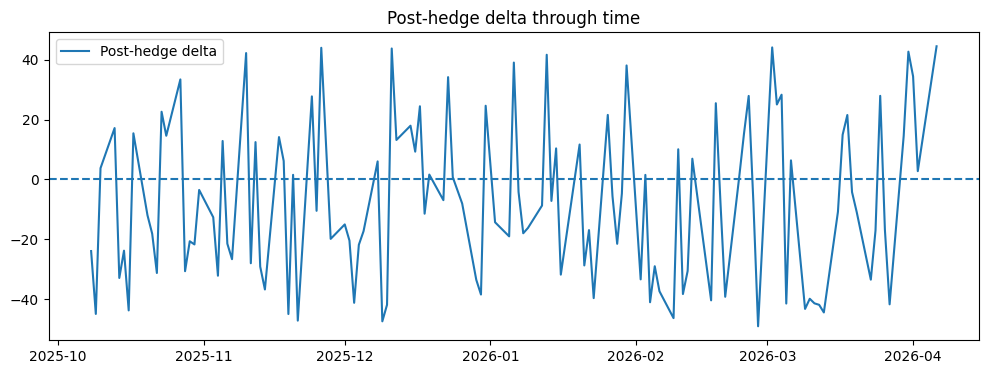

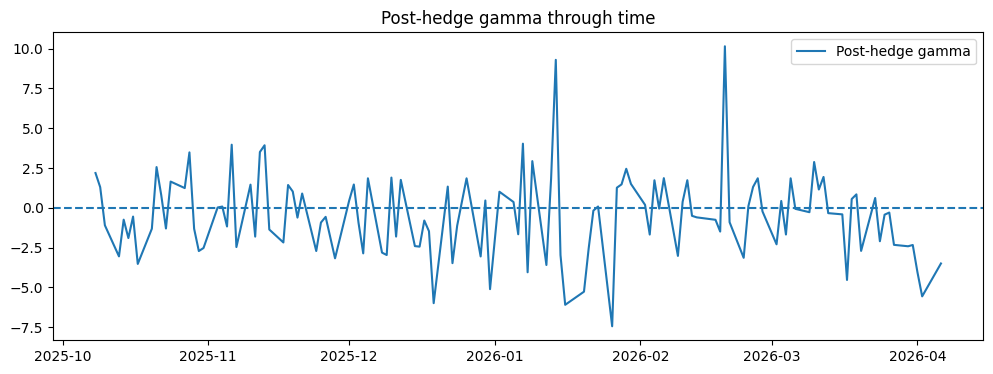

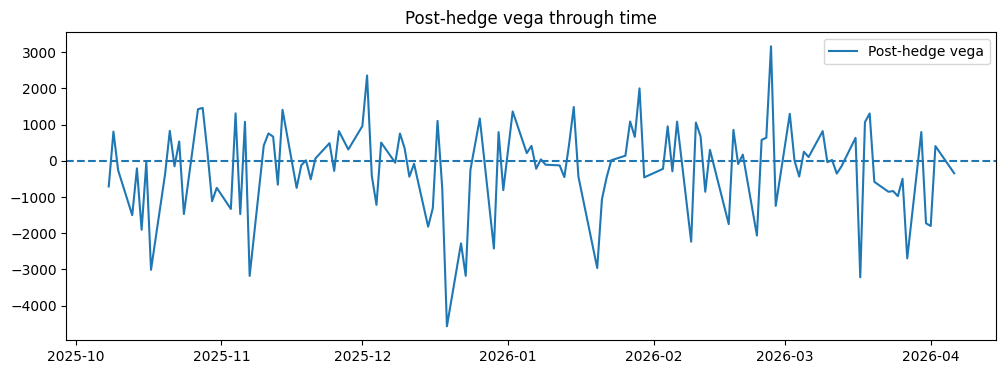

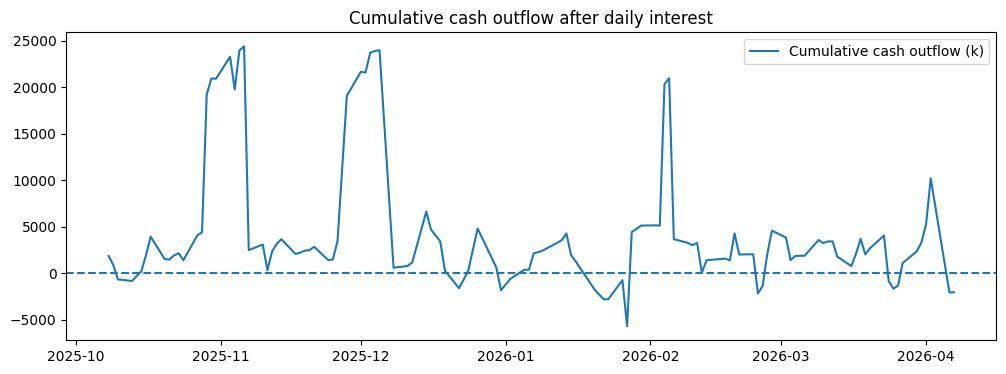

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_delta"], label="Post-hedge delta")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge delta through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_gamma"], label="Post-hedge gamma")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge gamma through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_vega"], label="Post-hedge vega")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge vega through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["cumulative_cash_outflow_after_interest_k"], label="Cumulative cash outflow (k)")
plt.axhline(0.0, linestyle="--")
plt.title("Cumulative cash outflow after daily interest")
plt.legend()
plt.show()

## 8. Final position book
This should be flat after the base-expiry liquidation step.


In [31]:
last_day_panel = panel_df.loc[panel_df["trade_date"] == history_df["trade_date"].max()].copy()

final_summary, final_details = portfolio_snapshot(
    day_panel=last_day_panel,
    option_positions=option_positions,
    stock_position=stock_position,
    contract_multiplier=CONTRACT_MULTIPLIER,
)

print("Final summary:")
display(pd.DataFrame([final_summary]))

print("Final option positions:")
display(final_details.sort_values("quantity_contracts", key=lambda s: s.abs(), ascending=False))

Final summary:


,stock_position_shares,option_value,total_delta,total_gamma,total_vega
0,-12300.0,NaN,NaN,NaN,NaN


Final option positions:


,contract_id,quantity_contracts,quantity_shares_equiv,price_per_share,delta_per_share,gamma_per_share,vega_per_share,position_delta,position_gamma,position_vega,position_value
7,2026-04-14|260.0|call,2155.0,215500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,2026-04-08|260.0|call,-1000.0,-100000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-06-08|250.0|call,-831.0,-83100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-25|260.0|call,162.0,16200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-05-23|260.0|call,6.0,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-05-22|260.0|call,5.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-06-10|250.0|put,5.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-06-08|250.0|put,2.0,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ---------------------------------------------------------
# Placeholder hook for the later DGV deep-dive cells
# ---------------------------------------------------------

# def solve_delta_gamma_vega(...):
#     ...
#     return {
#         "selected_hedge_id": "use this field if you keep one main label, or set to a custom summary string",
#         "target_option_book": target_option_book,
#         "target_stock_position": target_stock_position,
#         "hedge_contracts_theory": np.nan,   # or keep a custom encoding for the DGV deep-dive table
#         "hedge_contracts_actual": np.nan,
#         "stock_position_theory": stock_position_theory,
#         "stock_position_actual": stock_position_actual,
#         "targeted_greek": "delta_gamma_vega",
#         "residual_objective": residual_objective,
#     }

# STRATEGY_SOLVERS["delta_gamma_vega"] = solve_delta_gamma_vega
# strategies_to_compare = STRATEGIES_TO_RUN + ["delta_gamma_vega"]
# combined_history_df, combined_trade_log_df = run_multiple_strategies(
#     panel_df=panel_df,
#     regime_df=regime_df,
#     strategies_to_run=strategies_to_compare,
#     initial_underlying_shares=INITIAL_UNDERLYING_SHARES,
#     base_option_type=BASE_OPTION_TYPE,
#     base_position_sign=BASE_POSITION_SIGN,
#     target_entry_dte=TARGET_ENTRY_DTE,
#     target_hedge_dte=TARGET_HEDGE_DTE,
#     contract_multiplier=CONTRACT_MULTIPLIER,
#     max_single_candidates=MAX_SINGLE_CANDIDATES,
#     option_search_radius=OPTION_SEARCH_RADIUS,
#     stock_round_lot=STOCK_ROUND_LOT,
#     use_daily_risk_free_rate_for_cash=USE_DAILY_RISK_FREE_RATE_FOR_CASH,
#     manual_cash_rate=MANUAL_CASH_RATE,
# )


## 14. Save outputs


In [ ]:
combined_history_df.to_csv("unified_greek_strategy_history.csv", index=False)
combined_trade_log_df.to_csv("unified_greek_strategy_trade_log.csv", index=False)
summary_df.to_csv("unified_greek_strategy_summary.csv", index=False)

delta_daily_table.to_csv("delta_daily_table.csv", index=False)
delta_gamma_daily_table.to_csv("delta_gamma_daily_table.csv", index=False)
delta_vega_daily_table.to_csv("delta_vega_daily_table.csv", index=False)
delta_theta_daily_table.to_csv("delta_theta_daily_table.csv", index=False)

print("Saved CSV outputs to the current directory.")
